# Habituation / repeated-exposure analysis

This notebook generates the final analysis tables and draft figures for the habituation phase of the AIR Wheel behavioral experiment.

The goal is to quantify whether repeated head-fixed wheel exposure changes:

1. **whole-session locomotor state** across habituation sessions,
2. **within-session locomotor dynamics** across time in each session, and
3. whether the results are robust to animal-level variability.

Primary outcomes are restricted to the three measures reported in the manuscript:

- fraction moving,
- fraction forward,
- speed, defined as path speed in cm/s.

## 1. Analysis settings

These constants define the primary outcomes, labels, habituation phase name, movement threshold, and the common within-session analysis window.

In [1]:
PRIMARY_OUTCOMES = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

OUTCOME_LABELS = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Speed (cm/s)",
}

HAB_PHASE = "habituation"
SPEED_THRESH = 0.5
MAX_SESSION_TIME_MIN = 20.0

## 2. Load project context and cached behavioral epoch data

This section loads the project paths, epoch-window tables, behavioral epoch metrics, QC tables, and session-day metadata. The session-day table is used to identify good sessions and assign phase/session numbers.

In [3]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

# Find the project root that contains the src folder
current = Path.cwd().resolve()

for p in [current] + list(current.parents):
    if (p / "src").exists():
        repo_root = p
        break
else:
    raise FileNotFoundError("Could not find a folder containing 'src'.")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

print("Current working directory:", current)
print("Added repo root:", repo_root)
print("src exists:", (repo_root / "src").exists())

from pathlib import Path
import numpy as np
import pandas as pd

import src.utils.pdata_io as pdio
from src.proc.extract_epoch_windows import load_epoch_windows

data_root, pdata_root, cc_data = pdio.load_project_context()

windows_df = load_epoch_windows(
    pdata_root=pdata_root,
    filename="behavior_epoch_windows.h5",
    key="windows/prepost_1s"
)

valid_windows = windows_df[windows_df["valid_window"]].copy()

print("All windows:", windows_df.shape)
print("Valid windows:", valid_windows.shape)

valid_windows.groupby(["phase", "epoch_name"]).size().reset_index(name="n_windows")

encoder_epoch_df = pd.read_hdf(
    Path(pdata_root) / "_cache" / "behavior_epoch_metrics.h5",
    key="encoder/prepost_1s_speedThresh_1cms"
)

from src.qc.qc_events import load_behavior_qc_tables

events_df, session_summary_df = load_behavior_qc_tables(
    pdata_root=pdata_root,
    filename="behavior_QC.h5"
)

from src.utils.pdata_organize import make_session_availability_summary

session_availability_df = make_session_availability_summary(
    events_df=events_df,
    windows_df=windows_df,
    min_session_duration_s=900,
    min_valid_events=3,
)

from src.utils.pdata_organize import add_day_bins_to_sessions

session_day_df = add_day_bins_to_sessions(
    session_availability_df,
    use_good_sessions_only=True,
)

from pathlib import Path

# Make figures folder inside pdata directory
fig_dir = Path(pdata_root) / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

# Convert to string for R compatibility
fig_dir_str = str(fig_dir)
fig_dir

%load_ext rpy2.ipython

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current working directory: /home/nmldata2/ccaw/Python/notebooks
Added repo root: /home/nmldata2/ccaw/Python
src exists: True
[LOADED] Project context: /mnt/pdata/Classical_Conditioning/_cache/project_context.pkl
[LOADED] Epoch windows: /mnt/pdata/Classical_Conditioning/_cache/behavior_epoch_windows.h5
[KEY] windows/prepost_1s
All windows: (103980, 40)
Valid windows: (101861, 40)
[LOADED] Behavior QC tables: /mnt/pdata/Classical_Conditioning/_cache/behavior_QC.h5


### Inspect session-day metadata

This quick display is mainly a sanity check to confirm that session availability and phase/session numbering were loaded correctly.

In [4]:
session_day_df

,animal,date,phase,session_duration_s,n_events_total,n_events_valid,short_recording,enough_valid_events,good_session_basic,nwin_LED_off_post,...,nwin_tone_off_post,nwin_tone_off_pre,nwin_tone_on_post,nwin_tone_on_pre,n_valid_windows_total,date_dt,phase_day_number_good,n_good_sessions_in_phase,normalized_phase_day_good,phase_day_bin
0,NML_04,2025_12_27,habituation,1310.8,42,42,False,True,True,42,...,0,0,0,0,503,2025-12-27,1.0,16.0,0.000000,early
1,NML_04,2025_12_28,habituation,1473.4,43,43,False,True,True,43,...,0,0,0,0,516,2025-12-28,2.0,16.0,0.066667,early
2,NML_04,2025_12_29,habituation,1254.5,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-29,3.0,16.0,0.133333,early
3,NML_04,2025_12_30,habituation,1624.2,53,53,False,True,True,53,...,0,0,0,0,636,2025-12-30,4.0,16.0,0.200000,early
4,NML_04,2025_12_31,habituation,1326.6,41,41,False,True,True,41,...,0,0,0,0,492,2025-12-31,5.0,16.0,0.266667,early
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
208,NML_08,2026_03_17,tone_air_training,1235.7,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-17,6.0,10.0,0.555556,middle
209,NML_08,2026_03_18,tone_air_training,1236.0,51,51,False,True,True,0,...,51,51,51,51,612,2026-03-18,7.0,10.0,0.666667,middle
210,NML_08,2026_03_19,tone_air_training,1214.1,50,50,False,True,True,0,...,50,50,50,50,600,2026-03-19,8.0,10.0,0.777778,late
211,NML_08,2026_03_20,tone_air_training,1220.1,48,48,False,True,True,0,...,48,48,48,48,576,2026-03-20,9.0,10.0,0.888889,late


## 3. Define output folder for figures and tables

All draft figures and model-output tables are saved into the processed-data figure directory.

## 4. Whole-session habituation dataframe

Here we compute one row per animal-session using whole-session locomotor metrics. This dataframe is used for the first Results section: repeated exposure effects across habituation sessions.

In [ ]:
from src.proc.behavior_metrics import compute_whole_session_locomotor_metrics

hab_df = compute_whole_session_locomotor_metrics(
    session_day_df=session_summary_df,
    phase="habituation",
    speed_thresh=0.5,
    good_sessions_only=True,
)

hab_df.head()

### Save and reload the whole-session dataframe

The whole-session metrics are saved to HDF5 so that the analysis can be reproduced without recomputing them every time.

In [ ]:
from pathlib import Path
import src.utils.pdata_io as pdio

data_root, pdata_root, cc_data = pdio.load_project_context()

out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

pdio.save_df_h5(
    df=hab_df,
    h5_path=out_file,
    key="whole_session/habituation_speedThresh_0p5",
    overwrite=True,
    metadata={
        "phase": "habituation",
        "speed_thresh": 0.5,
        "good_sessions_only": True,
        "description": "Whole-session locomotor metrics for habituation phase",
    },
)

In [4]:
out_file = Path(pdata_root) / "_cache" / "behavior_whole_session_metrics.h5"

hab_df_loaded = pd.read_hdf(
    out_file,
    key="whole_session/habituation_speedThresh_0p5"
)

hab_df_loaded.head()

hab_df = hab_df_loaded.copy()

## 5. Prepare whole-session dataframe for LME

This section adds a unique animal-day/session identifier and creates `exposure_session_c`.

`exposure_session_c` is the exposure session number centered at the mean session number. The slope is still interpreted as change per additional exposure session.

In [8]:
hab_session_df = hab_df.copy()

# Animal-day/session ID
hab_session_df["animal_day"] = (
    hab_session_df["animal"].astype(str) + ":" +
    hab_session_df["date"].astype(str)
)

# Exposure session number
if "exposure_session" not in hab_session_df.columns:
    if "phase_session_number" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_session_number"]
    elif "phase_day_number_good" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day_number_good"]
    elif "phase_day" in hab_session_df.columns:
        hab_session_df["exposure_session"] = hab_session_df["phase_day"]
    else:
        raise ValueError("Could not find exposure/session/day column.")

hab_session_df["exposure_session"] = hab_session_df["exposure_session"].astype(float)

hab_session_df["exposure_session_c"] = (
    hab_session_df["exposure_session"] -
    hab_session_df["exposure_session"].mean()
)

print(hab_session_df.shape)
print(hab_session_df.columns.tolist())
display(hab_session_df.head())

(86, 55)
['animal', 'date', 'phase', 'fs', 'n_samples', 'recording_duration_s', 'short_recording', 'n_onsets', 'n_offsets', 'n_pairs', 'n_invalid_pair', 'n_edge_excluded', 'n_short_led', 'n_tone_structure_bad', 'n_short_recording_excluded', 'n_valid_for_epoch_extraction', 'status', 'date_dt', 'rig_day_from_date', 'rig_session_number', 'phase_day_from_date', 'phase_session_number', 'recording_duration_min', 'rig_session_start_s', 'rig_session_start_min', 'phase_session_start_s', 'phase_session_start_min', 'rig_calendar_day', 'phase_calendar_day', 'speed_thresh_cms', 'n_samples_used', 'duration_s_used', 'duration_min_used', 'total_distance_path_cm', 'total_distance_net_cm', 'distance_path_per_min', 'distance_net_per_min', 'net_direction_bias', 'mean_speed_path_cms', 'median_speed_path_cms', 'peak_speed_path_cms', 'mean_speed_net_cms', 'median_speed_net_cms', 'min_speed_net_cms', 'max_speed_net_cms', 'frac_stationary', 'frac_moving', 'frac_forward', 'frac_backward', 'frac_low_net_movement

,animal,date,phase,fs,n_samples,recording_duration_s,short_recording,n_onsets,n_offsets,n_pairs,...,frac_stationary,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,status_whole_session,animal_day,exposure_session,exposure_session_c
0,NML_04,2025_12_27,habituation,5000.0,6554000.0,1310.8,False,42.0,42.0,42.0,...,0.652482,0.347518,0.190179,0.157339,0.0,stationary,ok,NML_04:2025_12_27,1.0,-8.162791
1,NML_04,2025_12_28,habituation,5000.0,7367000.0,1473.4,False,43.0,43.0,43.0,...,0.688418,0.311582,0.169932,0.141649,0.0,stationary,ok,NML_04:2025_12_28,2.0,-7.162791
2,NML_04,2025_12_29,habituation,5000.0,6272500.0,1254.5,False,41.0,41.0,41.0,...,0.647617,0.352383,0.245342,0.107041,0.0,stationary,ok,NML_04:2025_12_29,3.0,-6.162791
3,NML_04,2025_12_30,habituation,5000.0,8121000.0,1624.2,False,53.0,53.0,53.0,...,0.664122,0.335878,0.268207,0.067671,0.0,stationary,ok,NML_04:2025_12_30,4.0,-5.162791
4,NML_04,2025_12_31,habituation,5000.0,6633000.0,1326.6,False,41.0,41.0,41.0,...,0.695495,0.304505,0.254244,0.050261,0.0,stationary,ok,NML_04:2025_12_31,5.0,-4.162791


## 6. Enable R in the notebook

The mixed-effects models are fit in R using `lme4`/`lmerTest`, while Python is used for data organization and saving tables.

In [13]:
%load_ext rpy2.ipython

## 7. Whole-session LME models

For each primary outcome, we fit:

`outcome ~ exposure_session_c + (1 | animal)`

This model asks whether the outcome changes across habituation sessions while allowing each animal to have its own baseline level.

In [9]:
%%R -i hab_session_df -o hab_session_results_R

library(lme4)
library(lmerTest)
library(broom.mixed)
library(dplyr)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

print(primary_outcomes)

# --------------------------------------------------
# Whole-session models
# outcome ~ exposure_session_c + (1 | animal)
# --------------------------------------------------

session_results <- list()
session_models <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting:", outcome, "\n")
  cat("==============================\n")

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c + (1 | animal)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_session_df,
    REML = FALSE
  )

  session_models[[outcome]] <- m

  tmp <- broom.mixed::tidy(
    m,
    effects = "fixed",
    conf.int = TRUE
  )

  tmp$outcome <- outcome
  session_results[[outcome]] <- tmp

  print(summary(m))
}

hab_session_results_R <- bind_rows(session_results) %>%
  relocate(outcome)

print(hab_session_results_R)

R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




[1] "frac_moving"         "frac_forward"        "mean_speed_path_cms"


Fitting: frac_moving 
Linear mixed model fit by maximum likelihood . t-tests use Satterthwaite's
  method [lmerModLmerTest]
Formula: as.formula(formula_text)
   Data: hab_session_df

      AIC       BIC    logLik -2*log(L)  df.resid 
    -78.7     -68.9      43.3     -86.7        82 

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-3.15800 -0.63575 -0.06073  0.52139  2.07859 

Random effects:
 Groups   Name        Variance Std.Dev.
 animal   (Intercept) 0.02893  0.1701  
 Residual             0.01756  0.1325  
Number of obs: 86, groups:  animal, 5

Fixed effects:
                    Estimate Std. Error        df t value Pr(>|t|)    
(Intercept)         0.308588   0.077405  5.023377   3.987   0.0104 *  
exposure_session_c  0.019879   0.002851 81.141128   6.974 7.53e-10 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr)
expsr_sssn

### Format whole-session model results for manuscript reporting

This converts the R fixed-effect output into compact manuscript-style statistical text.

In [10]:
import pandas as pd
import numpy as np

def format_p(p):
    if pd.isna(p):
        return "p = NA"
    elif p < 0.001:
        return "p < 0.001"
    else:
        return f"p = {p:.3f}"

def make_lme_report_table(df):
    report_df = df.copy()

    report_df["report_text"] = report_df.apply(
        lambda r: (
            f"β = {r['estimate']:.4f}, "
            f"SE = {r['std.error']:.4f}, "
            f"t({r['df']:.1f}) = {r['statistic']:.2f}, "
            f"{format_p(r['p.value'])}"
        ),
        axis=1
    )

    return report_df[
        ["outcome", "term", "estimate", "std.error", "statistic", "df", "p.value", "report_text"]
    ]

hab_session_report = make_lme_report_table(hab_session_results_R)

display(
    hab_session_report[
        hab_session_report["term"] != "(Intercept)"
    ]
)

,outcome,term,estimate,std.error,statistic,df,p.value,report_text
2,frac_moving,exposure_session_c,0.019879,0.002851,6.973667,81.141128,7.527844e-10,"β = 0.0199, SE = 0.0029, t(81.1) = 6.97, p < 0..."
4,frac_forward,exposure_session_c,0.022092,0.002938,7.520214,81.148312,6.512035e-11,"β = 0.0221, SE = 0.0029, t(81.1) = 7.52, p < 0..."
6,mean_speed_path_cms,exposure_session_c,0.263730,0.042159,6.255597,81.233242,1.751517e-08,"β = 0.2637, SE = 0.0422, t(81.2) = 6.26, p < 0..."


## 8. Figure 1A–C: whole-session repeated-exposure effects

This figure shows the raw animal-session values, individual animal trajectories, and the fixed-effect LME prediction for each primary outcome.

The figure is saved as PDF/PNG in the figure directory.

Fontconfig warning: using without calling FcInit()


              outcome          y_label       beta          se       df        t
1         frac_moving  Fraction moving 0.01987890 0.002850566 81.14113 6.973667
2        frac_forward Fraction forward 0.02209222 0.002937712 81.14831 7.520214
3 mean_speed_path_cms     Speed (cm/s) 0.26372985 0.042159020 81.23324 6.255597
             p        stat_label
1 7.527844e-10 β = 0.020/session
2 6.512035e-11 β = 0.022/session
3 1.751517e-08 β = 0.264/session


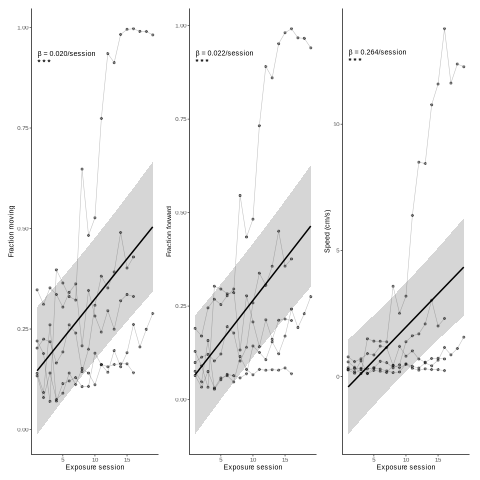

In [11]:
%%R -i hab_session_df -i fig_dir_str

library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)
library(patchwork)

# --------------------------------------------------
# Output folder
# --------------------------------------------------

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_session_df$animal <- factor(hab_session_df$animal)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Helper: p-value formatting
# --------------------------------------------------

format_p <- function(p) {
  if (is.na(p)) {
    return("")
  } else if (p < 0.001) {
    return("*\u2009*\u2009*")
  } else if (p < 0.01) {
    return("*\u2009*")
  } else if (p < 0.05) {
    return("*")
  } else {
    return("ns")
  }
}

# --------------------------------------------------
# Helper: fixed-effect prediction with 95% CI
# --------------------------------------------------

predict_fixed_ci <- function(model, newdata) {
  fixed_formula <- formula(model, fixed.only = TRUE)
  X <- model.matrix(delete.response(terms(fixed_formula)), newdata)
  beta <- fixef(model)
  V <- vcov(model)

  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% V %*% t(X)))

  newdata$fit <- fit
  newdata$se <- se
  newdata$lower <- fit - 1.96 * se
  newdata$upper <- fit + 1.96 * se

  return(newdata)
}

# --------------------------------------------------
# Theme
# --------------------------------------------------

theme_fig <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text = element_text(size = 6),
      plot.title = element_blank(),
      plot.subtitle = element_blank(),
      legend.position = "none",
      plot.margin = margin(3, 5, 3, 3)
    )
}

# --------------------------------------------------
# Fit models and make one plot per outcome
# --------------------------------------------------

plot_list <- list()
stats_list <- list()

for (outcome in primary_outcomes) {

  label_i <- unname(outcome_labels[outcome])

  m <- lmer(
    as.formula(paste0(outcome, " ~ exposure_session_c + (1 | animal)")),
    data = hab_session_df,
    REML = FALSE
  )

  sm <- summary(m)
  coef_table <- as.data.frame(sm$coefficients)

  beta <- coef_table["exposure_session_c", "Estimate"]
  se <- coef_table["exposure_session_c", "Std. Error"]
  df <- coef_table["exposure_session_c", "df"]
  tval <- coef_table["exposure_session_c", "t value"]
  pval <- coef_table["exposure_session_c", "Pr(>|t|)"]

  # Use plain "beta" to avoid Greek font/rendering problems
  stat_label <- paste0(
    "\u03B2 = ", sprintf("%.3f", beta), "/session"
  )

  stat_label_stars <- format_p(pval)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    y_label = label_i,
    beta = beta,
    se = se,
    df = df,
    t = tval,
    p = pval,
    stat_label = stat_label
  )

  exposure_seq <- seq(
    min(hab_session_df$exposure_session, na.rm = TRUE),
    max(hab_session_df$exposure_session, na.rm = TRUE),
    length.out = 100
  )

  exposure_mean <- mean(hab_session_df$exposure_session, na.rm = TRUE)

  pred_df <- data.frame(
    exposure_session = exposure_seq,
    exposure_session_c = exposure_seq - exposure_mean
  )

  pred_df <- predict_fixed_ci(m, pred_df)

  raw_df <- hab_session_df %>%
    select(animal, exposure_session, all_of(outcome)) %>%
    rename(y = all_of(outcome))

  x_annot <- min(raw_df$exposure_session, na.rm = TRUE) +
    0.003 * diff(range(raw_df$exposure_session, na.rm = TRUE))

  y_annot <- max(raw_df$y, na.rm = TRUE) -
    0.06 * diff(range(raw_df$y, na.rm = TRUE))

  p <- ggplot() +
    geom_line(
      data = raw_df,
      aes(x = exposure_session, y = y, group = animal),
      alpha = 0.25,
      linewidth = 0.25
    ) +
    geom_point(
      data = raw_df,
      aes(x = exposure_session, y = y),
      alpha = 0.45,
      size = 0.8
    ) +
    geom_ribbon(
      data = pred_df,
      aes(x = exposure_session, ymin = lower, ymax = upper),
      alpha = 0.20
    ) +
    geom_line(
      data = pred_df,
      aes(x = exposure_session, y = fit),
      linewidth = 0.7
    ) +
    annotate(
      "text",
      x = x_annot,
      y = y_annot,
      label = stat_label,
      hjust = 0,
      vjust = 1,
      size = 2.5
    ) +
    annotate(
      "text",
      x = x_annot,
      y = y_annot,
      label = stat_label_stars,
      hjust = 0,
      vjust = 2.7,
      size = 2.7,
      fontface = "bold"
    ) +
    labs(
      x = "Exposure session",
      y = label_i
    ) +
    theme_fig()

  plot_list[[outcome]] <- p
}

# --------------------------------------------------
# Combine panels
# --------------------------------------------------

p_combined <- plot_list[[primary_outcomes[1]]] +
  plot_list[[primary_outcomes[2]]] +
  plot_list[[primary_outcomes[3]]] +
  plot_layout(nrow = 1)

print(p_combined)

# --------------------------------------------------
# Save
# --------------------------------------------------

ggsave(
  filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.pdf"),
  plot = p_combined,
  width = 7,
  height = 1.5,
  device = cairo_pdf
)

# ggsave(
#   filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.png"),
#   plot = p_combined,
#   width = 7,
#   height = 1.9,
#   dpi = 600
# )

# # SVG should work after installing r-svglite
# ggsave(
#   filename = file.path(out_dir, "Fig1_whole_session_habituation_3panel.svg"),
#   plot = p_combined,
#   width = 7,
#   height = 1.9
# )

# --------------------------------------------------
# Save stats table
# --------------------------------------------------

hab_whole_session_stats_df <- bind_rows(stats_list)

write.csv(
  hab_whole_session_stats_df,
  file.path(out_dir, "habituation_whole_session_LME_stats.csv"),
  row.names = FALSE
)

print(hab_whole_session_stats_df)

## 9. Animal-level sensitivity analysis

The whole-session figure shows that one animal has a particularly large increase, especially for speed. To check whether the repeated-exposure effect is driven only by this high-responder, we estimate a separate slope for each animal and summarize how many animals show a positive slope.

In [12]:
%%R -i hab_session_df -o animal_slope_results_df -o animal_slope_summary_df

library(dplyr)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

animal_slope_results <- list()

for (outcome in primary_outcomes) {

  tmp <- hab_session_df %>%
    group_by(animal) %>%
    group_modify(~{
      fit <- lm(as.formula(paste0(outcome, " ~ exposure_session")), data = .x)
      coefs <- summary(fit)$coefficients

      data.frame(
        n_sessions = nrow(.x),
        df = df.residual(fit),
        beta = coefs["exposure_session", "Estimate"],
        se = coefs["exposure_session", "Std. Error"],
        t = coefs["exposure_session", "t value"],
        p = coefs["exposure_session", "Pr(>|t|)"]
      )
    }) %>%
    ungroup() %>%
    mutate(outcome = outcome)

  animal_slope_results[[outcome]] <- tmp
}

animal_slope_results_df <- bind_rows(animal_slope_results)

animal_slope_summary_df <- animal_slope_results_df %>%
  group_by(outcome) %>%
  summarise(
    n_animals = n(),
    n_positive = sum(beta > 0),
    mean_beta = mean(beta, na.rm = TRUE),
    median_beta = median(beta, na.rm = TRUE),
    min_beta = min(beta, na.rm = TRUE),
    max_beta = max(beta, na.rm = TRUE),
    .groups = "drop"
  )

print(animal_slope_results_df)
print(animal_slope_summary_df)

# A tibble: 15 × 8
   animal n_sessions    df     beta      se      t        p outcome            
   <chr>       <int> <int>    <dbl>   <dbl>  <dbl>    <dbl> <chr>              
 1 NML_04         16    14 -0.00253 0.00240 -1.05  3.10e- 1 frac_moving        
 2 NML_05         16    14  0.0187  0.00326  5.73  5.24e- 5 frac_moving        
 3 NML_06         16    14  0.00412 0.00128  3.20  6.38e- 3 frac_moving        
 4 NML_07         19    17  0.0556  0.00480 11.6   1.70e- 9 frac_moving        
 5 NML_08         19    17  0.00738 0.00207  3.57  2.35e- 3 frac_moving        
 6 NML_04         16    14 -0.00221 0.00274 -0.808 4.33e- 1 frac_forward       
 7 NML_05         16    14  0.0228  0.00296  7.70  2.14e- 6 frac_forward       
 8 NML_06         16    14  0.00216 0.00100  2.16  4.88e- 2 frac_forward       
 9 NML_07         19    17  0.0593  0.00451 13.1   2.49e-10 frac_forward       
10 NML_08         19    17  0.0106  0.00178  5.93  1.64e- 5 frac_forward       
11 NML_04         16 

### Leave-one-animal-out sensitivity analysis

This optional sensitivity analysis refits the whole-session LME after removing one animal at a time. The goal is to determine whether the exposure-session effect remains positive when any single animal is excluded.

In [13]:
%%R -i hab_session_df

library(lme4)
library(lmerTest)
library(dplyr)

hab_session_df$animal <- factor(hab_session_df$animal)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_session_df)]

loo_results <- list()

for (outcome in primary_outcomes) {

  animals <- levels(hab_session_df$animal)

  for (a in animals) {

    df_sub <- hab_session_df %>%
      filter(animal != a)

    m <- lmer(
      as.formula(paste0(outcome, " ~ exposure_session_c + (1 | animal)")),
      data = df_sub,
      REML = FALSE
    )

    coef_table <- as.data.frame(summary(m)$coefficients)

    loo_results[[paste(outcome, a, sep = "_")]] <- data.frame(
      outcome = outcome,
      animal_removed = a,
      beta = coef_table["exposure_session_c", "Estimate"],
      se = coef_table["exposure_session_c", "Std. Error"],
      df = coef_table["exposure_session_c", "df"],
      t = coef_table["exposure_session_c", "t value"],
      p = coef_table["exposure_session_c", "Pr(>|t|)"]
    )
  }
}

loo_results_df <- bind_rows(loo_results)

print(loo_results_df)

               outcome animal_removed        beta          se       df        t
1          frac_moving         NML_04 0.024053330 0.003151642 66.09173 7.632001
2          frac_moving         NML_05 0.020095894 0.003377964 66.10311 5.949115
3          frac_moving         NML_06 0.022787940 0.003307717 66.13597 6.889326
4          frac_moving         NML_07 0.006948889 0.001439411 63.06828 4.827592
5          frac_moving         NML_08 0.024449197 0.003547693 63.10872 6.891577
6         frac_forward         NML_04 0.026610313 0.003210122 66.09389 8.289503
7         frac_forward         NML_05 0.021955547 0.003496016 66.10904 6.280162
8         frac_forward         NML_06 0.025778122 0.003347551 66.13725 7.700591
9         frac_forward         NML_07 0.008613373 0.001539203 63.10174 5.595997
10        frac_forward         NML_08 0.026310290 0.003708730 63.11232 7.094151
11 mean_speed_path_cms         NML_04 0.313848541 0.048373757 66.16863 6.487992
12 mean_speed_path_cms         NML_05 0.

## 10. Build epoch-level habituation dataframe

The within-session analysis requires an epoch-level dataframe, not the whole-session dataframe. Here we extract habituation epochs from `encoder_epoch_df`, add animal-day IDs, add exposure-session numbers, add within-session time, and keep only the primary outcomes.

`session_time_10m_c` is within-session time centered at the mean sampled time and scaled by 10 minutes. Its coefficient is interpreted as change per 10 minutes later within a session.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Build habituation epoch-level dataframe
# --------------------------------------------------

df0 = encoder_epoch_df.copy()

print("Available phases:")
print(df0["phase"].value_counts())

# Detect habituation phase
phase_vals = df0["phase"].dropna().astype(str).unique().tolist()

if "habituation" in phase_vals:
    hab_phase = "habituation"
else:
    hab_candidates = [
        p for p in phase_vals
        if ("hab" in p.lower()) or ("exposure" in p.lower())
    ]
    if len(hab_candidates) == 0:
        raise ValueError(f"Could not identify habituation phase. Available phases: {phase_vals}")
    hab_phase = hab_candidates[0]

print("Using habituation phase:", hab_phase)

hab_epoch_df = df0[df0["phase"].astype(str) == hab_phase].copy()

# --------------------------------------------------
# Apply validity filters if columns exist
# --------------------------------------------------

if "valid_window" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["valid_window"] == True].copy()

if "good_session_basic" in hab_epoch_df.columns:
    hab_epoch_df = hab_epoch_df[hab_epoch_df["good_session_basic"] == True].copy()

# --------------------------------------------------
# Animal-day/session ID
# --------------------------------------------------

if "date" in hab_epoch_df.columns:
    hab_epoch_df["animal_day"] = (
        hab_epoch_df["animal"].astype(str) + ":" +
        hab_epoch_df["date"].astype(str)
    )
else:
    raise ValueError("date column not found; need a session/date identifier.")

# --------------------------------------------------
# Add exposure session number
# --------------------------------------------------

if "exposure_session" not in hab_epoch_df.columns:
    if "phase_session_number" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_session_number"]
    elif "phase_day_number_good" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day_number_good"]
    elif "phase_day" in hab_epoch_df.columns:
        hab_epoch_df["exposure_session"] = hab_epoch_df["phase_day"]
    else:
        # Try merging from session_day_df if available
        if "session_day_df" in globals():
            merge_cols = ["animal", "date"]
            possible_session_cols = [
                "phase_session_number",
                "phase_day_number_good",
                "phase_day",
                "training_day",
            ]
            available_session_cols = [
                c for c in possible_session_cols if c in session_day_df.columns
            ]

            if len(available_session_cols) == 0:
                raise ValueError(
                    "No session/day column found in hab_epoch_df or session_day_df."
                )

            session_col = available_session_cols[0]

            hab_epoch_df = hab_epoch_df.merge(
                session_day_df[merge_cols + [session_col]].drop_duplicates(),
                on=merge_cols,
                how="left"
            )

            hab_epoch_df["exposure_session"] = hab_epoch_df[session_col]
        else:
            raise ValueError(
                "Could not find exposure/session/day column and session_day_df is not available."
            )

hab_epoch_df["exposure_session"] = hab_epoch_df["exposure_session"].astype(float)

# --------------------------------------------------
# Add within-session time in minutes
# --------------------------------------------------

if "session_time_min" not in hab_epoch_df.columns:
    if "anchor_session_time_min" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_session_time_min"]
    elif "window_center_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["window_center_time_s"] / 60.0
    elif "anchor_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["anchor_time_s"] / 60.0
    elif "session_time_s" in hab_epoch_df.columns:
        hab_epoch_df["session_time_min"] = hab_epoch_df["session_time_s"] / 60.0
    else:
        print("Time-related columns:")
        print([c for c in hab_epoch_df.columns if "time" in c.lower()])
        raise ValueError("Could not find a within-session time column.")

# --------------------------------------------------
# Make centered predictors
# --------------------------------------------------

hab_epoch_df["exposure_session_c"] = (
    hab_epoch_df["exposure_session"] -
    hab_epoch_df["exposure_session"].mean()
)

hab_epoch_df["session_time_10m_c"] = (
    hab_epoch_df["session_time_min"] -
    hab_epoch_df["session_time_min"].mean()
) / 10.0

# --------------------------------------------------
# Make sure primary outcomes exist
# --------------------------------------------------

if "frac_moving" not in hab_epoch_df.columns:
    if "frac_stationary" in hab_epoch_df.columns:
        hab_epoch_df["frac_moving"] = 1 - hab_epoch_df["frac_stationary"]
    elif "stationary_frac" in hab_epoch_df.columns:
        hab_epoch_df["frac_moving"] = 1 - hab_epoch_df["stationary_frac"]

primary_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

missing = [c for c in primary_outcomes if c not in hab_epoch_df.columns]
if len(missing) > 0:
    print("Missing primary outcomes:", missing)
    print("Available fraction columns:")
    print([c for c in hab_epoch_df.columns if "frac" in c.lower()])
    print("Available speed columns:")
    print([c for c in hab_epoch_df.columns if "speed" in c.lower()])
    raise ValueError("Some primary outcome columns are missing.")

# --------------------------------------------------
# Drop rows missing required values
# --------------------------------------------------

required_cols = [
    "animal",
    "animal_day",
    "exposure_session",
    "exposure_session_c",
    "session_time_min",
    "session_time_10m_c",
] + primary_outcomes

hab_epoch_df = hab_epoch_df.dropna(subset=required_cols).copy()

# --------------------------------------------------
# Summary
# --------------------------------------------------

print("hab_epoch_df shape:", hab_epoch_df.shape)
print("n animals:", hab_epoch_df["animal"].nunique())
print("n animal-day sessions:", hab_epoch_df["animal_day"].nunique())
print("n sampled epoch windows:", len(hab_epoch_df))

print("\nExposure session summary:")
display(hab_epoch_df["exposure_session"].describe())

print("\nSession time summary:")
display(hab_epoch_df["session_time_min"].describe())

print("\nMean session time subtracted:")
print(hab_epoch_df["session_time_min"].mean())

print("\nOutcome summaries:")
display(hab_epoch_df[primary_outcomes].describe())

display(hab_epoch_df.head())

hab_epoch_df_original = hab_epoch_df.copy()


Available phases:
phase
air_training         42362
habituation          38237
tone_air_training    21262
Name: count, dtype: int64
Using habituation phase: habituation
hab_epoch_df shape: (38237, 64)
n animals: 5
n animal-day sessions: 85
n sampled epoch windows: 38237

Exposure session summary:


count    38237.000000
mean         9.539765
std          4.973974
min          1.000000
25%          5.000000
50%         10.000000
75%         14.000000
max         19.000000
Name: exposure_session, dtype: float64


Session time summary:


count    38237.000000
mean        11.397382
std          6.702021
min          0.035327
25%          5.813273
50%         11.197920
75%         16.561718
max         42.373018
Name: session_time_min, dtype: float64


Mean session time subtracted:
11.397382056126363

Outcome summaries:


,frac_moving,frac_forward,mean_speed_path_cms
count,38237.000000,38237.000000,38237.000000
mean,0.325387,0.262891,1.858992
std,0.409532,0.378257,3.639495
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.033200,0.000000,0.092287
75%,0.802400,0.474000,1.606133
max,1.000000,1.000000,20.434376


,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,animal_day,exposure_session,session_time_min,exposure_session_c,session_time_10m_c
42362,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,post,1.0,LED_off_mid_post_1s,...,0.7754,0.4378,0.3376,0.0,forward,NML_04:2025_12_27,1.0,1.575325,-8.539765,-0.982206
42363,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,pre,1.0,LED_off_mid_pre_1s,...,0.8246,0.4530,0.3716,0.0,forward,NML_04:2025_12_27,1.0,1.575325,-8.539765,-0.982206
42364,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,post,1.0,LED_off_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,1.450453,-8.539765,-0.994693
42365,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,pre,1.0,LED_off_pre_1s,...,0.3184,0.2738,0.0446,0.0,stationary,NML_04:2025_12_27,1.0,1.450453,-8.539765,-0.994693
42366,NML_04,2025_12_27,habituation,0,LED_on_mid,middle,79.535099,post,1.0,LED_on_mid_post_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,1.325585,-8.539765,-1.007180


In [ ]:
valid_anchors = ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"]

hab_epoch_df_pre = hab_epoch_df[
    (hab_epoch_df["window_position"] == "pre") &
    (hab_epoch_df["anchor_name"].isin(valid_anchors))
].copy()



## 11. Diagnose session duration

Before fitting within-session models, we inspect the time columns and the maximum session time per animal-day. This is important because one recording extends beyond the typical 20-minute session duration.

In [8]:
# Check time-related columns in encoder_epoch_df and hab_epoch_df if it exists
for df_name in ["encoder_epoch_df", "hab_epoch_df_pre", "windows_df", "valid_windows"]:
    if df_name in globals():
        df = globals()[df_name]
        print("\n", df_name, df.shape)
        print([c for c in df.columns if "time" in c.lower() or "anchor" in c.lower() or "window" in c.lower()])


 encoder_epoch_df (101861, 59)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_window', 'anchor_warning', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min', 'n_samples_window']

 hab_epoch_df_pre (12752, 64)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_window', 'anchor_warning', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min', 'n_samples_window', 'session_time_min', 'session_time_10m_c']

 windows_df (103980, 40)
['anchor_name', 'anchor_type', 'anchor_time_s', 'window_position', 'window_s', 'window_start_s', 'window_end_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'valid_window_basic', 'valid_wind

In [9]:
# Check per-session max within-session time
tmp = hab_epoch_df_pre.copy()

session_time_check = (
    tmp.groupby(["animal", "date", "animal_day"], observed=True)
    .agg(
        n_windows=("session_time_min", "size"),
        min_time_min=("session_time_min", "min"),
        max_time_min=("session_time_min", "max"),
        mean_time_min=("session_time_min", "mean"),
    )
    .reset_index()
    .sort_values("max_time_min", ascending=False)
)

display(session_time_check.head(20))

print("Number of sessions with max time > 25 min:")
print((session_time_check["max_time_min"] > 25).sum())

display(session_time_check[session_time_check["max_time_min"] > 25])

,animal,date,animal_day,n_windows,min_time_min,max_time_min,mean_time_min
79,NML_08,2026_02_15,NML_08:2026_02_15,164,21.917293,42.373018,32.190604
35,NML_06,2025_12_30,NML_06:2025_12_30,240,0.336637,30.181679,15.259103
84,NML_08,2026_02_20,NML_08:2026_02_20,215,0.392477,26.976664,13.753212
3,NML_04,2025_12_30,NML_04:2025_12_30,212,0.460023,26.808667,13.634286
12,NML_04,2026_01_08,NML_04:2026_01_08,204,0.378357,25.727993,13.053110
19,NML_05,2025_12_30,NML_05:2025_12_30,196,0.568610,24.919250,12.743875
32,NML_06,2025_12_27,NML_06:2025_12_27,184,0.939207,23.791494,12.365283
43,NML_06,2026_01_07,NML_06:2026_01_07,187,0.489123,23.633329,12.101847
1,NML_04,2025_12_28,NML_04:2025_12_28,172,2.215513,23.560504,12.892123
21,NML_05,2026_01_01,NML_05:2026_01_01,184,0.702560,23.349823,12.125865


Number of sessions with max time > 25 min:
5


,animal,date,animal_day,n_windows,min_time_min,max_time_min,mean_time_min
79,NML_08,2026_02_15,NML_08:2026_02_15,164,21.917293,42.373018,32.190604
35,NML_06,2025_12_30,NML_06:2025_12_30,240,0.336637,30.181679,15.259103
84,NML_08,2026_02_20,NML_08:2026_02_20,215,0.392477,26.976664,13.753212
3,NML_04,2025_12_30,NML_04:2025_12_30,212,0.460023,26.808667,13.634286
12,NML_04,2026_01_08,NML_04:2026_01_08,204,0.378357,25.727993,13.053110


## 12. Restrict within-session analysis to the common first 20 minutes

Most habituation sessions were approximately 20 minutes. One session extended to about 42 minutes, so the final within-session analysis is restricted to the first 20 minutes of each session to keep temporal coverage comparable across animals and sessions.

After filtering, `exposure_session_c` and `session_time_10m_c` are recalculated.

In [10]:
# --------------------------------------------------
# Restrict within-session analysis to common 20-min window
# --------------------------------------------------

ANALYSIS_MAX_MIN = 20.0

hab_epoch_df_20min_pre = hab_epoch_df_pre[
    (hab_epoch_df_pre["session_time_min"] >= 0) &
    (hab_epoch_df_pre["session_time_min"] <= ANALYSIS_MAX_MIN)
].copy()

# Re-center after filtering
hab_epoch_df_20min_pre["exposure_session_c"] = (
    hab_epoch_df_20min_pre["exposure_session"] -
    hab_epoch_df_20min_pre["exposure_session"].mean()
)

hab_epoch_df_20min_pre["session_time_10m_c"] = (
    hab_epoch_df_20min_pre["session_time_min"] -
    hab_epoch_df_20min_pre["session_time_min"].mean()
) / 10.0

print("Original hab_epoch_df:", hab_epoch_df_pre.shape)
print("Restricted hab_epoch_df_20min_pre:", hab_epoch_df_20min_pre.shape)

print("\nSession time summary after restriction:")
display(hab_epoch_df_20min_pre["session_time_min"].describe())

print("\nMean session time subtracted:")
print(hab_epoch_df_20min_pre["session_time_min"].mean())

print("\nNumber of animals:", hab_epoch_df_20min_pre["animal"].nunique())
print("Number of sessions:", hab_epoch_df_20min_pre["animal_day"].nunique())
print("Number of sampled windows:", len(hab_epoch_df_20min_pre))

# hab_epoch_df = hab_epoch_df_20min_pre.copy()

Original hab_epoch_df: (12752, 64)
Restricted hab_epoch_df_20min_pre: (11546, 64)

Session time summary after restriction:


count    11546.000000
mean        10.252536
std          5.631236
min          0.035327
25%          5.373935
50%         10.244633
75%         15.146287
max         19.997972
Name: session_time_min, dtype: float64


Mean session time subtracted:
10.252536388597743

Number of animals: 5
Number of sessions: 84
Number of sampled windows: 11546


In [11]:
hab_epoch_df_20min_pre.head()

,animal,date,phase,event_number,anchor_name,anchor_type,anchor_time_s,window_position,window_s,epoch_name,...,frac_moving,frac_forward,frac_backward,frac_low_net_movement,dominant_locomotor_state,animal_day,exposure_session,session_time_min,exposure_session_c,session_time_10m_c
42363,NML_04,2025_12_27,habituation,0,LED_off_mid,middle,94.519501,pre,1.0,LED_off_mid_pre_1s,...,0.8246,0.4530,0.3716,0.0,forward,NML_04:2025_12_27,1.0,1.575325,-8.502338,-0.867721
42365,NML_04,2025_12_27,habituation,0,LED_off,main,87.027199,pre,1.0,LED_off_pre_1s,...,0.3184,0.2738,0.0446,0.0,stationary,NML_04:2025_12_27,1.0,1.450453,-8.502338,-0.880208
42367,NML_04,2025_12_27,habituation,0,LED_on_mid,middle,79.535099,pre,1.0,LED_on_mid_pre_1s,...,0.1304,0.0000,0.1304,0.0,stationary,NML_04:2025_12_27,1.0,1.325585,-8.502338,-0.892695
42369,NML_04,2025_12_27,habituation,0,LED_on,main,72.042999,pre,1.0,LED_on_pre_1s,...,0.9582,0.5606,0.3976,0.0,forward,NML_04:2025_12_27,1.0,1.200717,-8.502338,-0.905182
42375,NML_04,2025_12_27,habituation,1,LED_off_mid,middle,124.489498,pre,1.0,LED_off_mid_pre_1s,...,0.0000,0.0000,0.0000,0.0,stationary,NML_04:2025_12_27,1.0,2.074825,-8.502338,-0.817771


## 13. Sensitivity check: unrestricted vs. first-20-min within-session models

This section fits the same epoch-level LME to both the unrestricted dataframe and the first-20-minute restricted dataframe. We compare the key terms:

- exposure session,
- within-session time,
- exposure session × within-session time.

This tells us whether the 20-minute restriction changes the reported model conclusions.

In [14]:
%%R -i hab_epoch_df_pre -i hab_epoch_df_20min_pre -o hab_epoch_restriction_comparison_df

library(lme4)
library(lmerTest)
library(dplyr)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

run_epoch_model_summary <- function(df, dataset_label) {

  df$animal <- factor(df$animal)
  df$animal_day <- factor(df$animal_day)

  results <- list()

  for (outcome in primary_outcomes) {

    if (!(outcome %in% names(df))) {
      next
    }

    formula_text <- paste0(
      outcome,
      " ~ exposure_session_c * session_time_10m_c + ",
      "(1 | animal) + (1 | animal_day)"
    )

    m <- lmer(
      as.formula(formula_text),
      data = df,
      REML = FALSE,
      control = lmerControl(
        optimizer = "bobyqa",
        optCtrl = list(maxfun = 2e5)
      )
    )

    coef_table <- as.data.frame(summary(m)$coefficients)

    tmp <- data.frame(
      dataset = dataset_label,
      outcome = outcome,
      term = rownames(coef_table),
      beta = coef_table[, "Estimate"],
      se = coef_table[, "Std. Error"],
      df = coef_table[, "df"],
      t = coef_table[, "t value"],
      p = coef_table[, "Pr(>|t|)"],
      n_obs = nobs(m),
      row.names = NULL
    )

    results[[outcome]] <- tmp
  }

  bind_rows(results)
}


unrestricted_df <- run_epoch_model_summary(hab_epoch_df_pre, "unrestricted")
restricted_df <- run_epoch_model_summary(hab_epoch_df_20min_pre, "first_20_min")

hab_epoch_restriction_comparison_df <- bind_rows(
  unrestricted_df,
  restricted_df
) %>%
  filter(term %in% c(
    "exposure_session_c",
    "session_time_10m_c",
    "exposure_session_c:session_time_10m_c"
  ))

print(hab_epoch_restriction_comparison_df)

R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




        dataset             outcome                                  term
1  unrestricted         frac_moving                    exposure_session_c
2  unrestricted         frac_moving                    session_time_10m_c
3  unrestricted         frac_moving exposure_session_c:session_time_10m_c
4  unrestricted        frac_forward                    exposure_session_c
5  unrestricted        frac_forward                    session_time_10m_c
6  unrestricted        frac_forward exposure_session_c:session_time_10m_c
7  unrestricted mean_speed_path_cms                    exposure_session_c
8  unrestricted mean_speed_path_cms                    session_time_10m_c
9  unrestricted mean_speed_path_cms exposure_session_c:session_time_10m_c
10 first_20_min         frac_moving                    exposure_session_c
11 first_20_min         frac_moving                    session_time_10m_c
12 first_20_min         frac_moving exposure_session_c:session_time_10m_c
13 first_20_min        frac_forward   

In [15]:
hab_epoch_restriction_comparison_df

,dataset,outcome,term,beta,se,df,t,p,n_obs
1,unrestricted,frac_moving,exposure_session_c,0.018655,0.002874,74.628180,6.490105,8.390419e-09,12752
2,unrestricted,frac_moving,session_time_10m_c,-0.026708,0.004648,12745.567480,-5.746553,9.316587e-09,12752
3,unrestricted,frac_moving,exposure_session_c:session_time_10m_c,0.000283,0.000913,12747.041372,0.310194,7.564188e-01,12752
4,unrestricted,frac_forward,exposure_session_c,0.020727,0.002962,76.838090,6.996521,8.514281e-10,12752
5,unrestricted,frac_forward,session_time_10m_c,-0.013796,0.003992,12742.977432,-3.455999,5.500439e-04,12752
6,unrestricted,frac_forward,exposure_session_c:session_time_10m_c,-0.000158,0.000784,12737.993562,-0.200880,8.407958e-01,12752
7,unrestricted,mean_speed_path_cms,exposure_session_c,0.263403,0.042602,80.070642,6.182831,2.497607e-08,12752
8,unrestricted,mean_speed_path_cms,session_time_10m_c,0.021381,0.026731,12689.739282,0.799835,4.238215e-01,12752
9,unrestricted,mean_speed_path_cms,exposure_session_c:session_time_10m_c,0.016909,0.005252,12687.209689,3.219609,1.286886e-03,12752
10,first_20_min,frac_moving,exposure_session_c,0.018948,0.002855,74.218128,6.637313,4.578238e-09,11546


## 14. Final within-session LME models and Figure 1D–F

For the final within-session analysis, we use the first-20-minute restricted dataframe and fit:

`outcome ~ exposure_session_c * session_time_10m_c + (1 | animal) + (1 | animal_day)`

This model asks whether locomotor state and speed change:

1. across exposure sessions,
2. across time within a session, and
3. whether the within-session time profile changes across exposure sessions.

The figure displays binned raw means and fixed-effect model predictions for early, mean, and late exposure. Interaction statistics are saved in the output table and reported in the Results/caption rather than written inside the plot panels.

R[write to console]: Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'





Fitting: frac_moving 


Fitting: frac_forward 


Fitting: mean_speed_path_cms 
 exposure_session_c session_time_10m_c.trend         SE       df    lower.CL
          -6.502338               -0.1039483 0.05221971 11468.87 -0.20630785
           0.000000                0.0578596 0.03113983 11465.30 -0.00317978
           6.497662                0.2195511 0.05112859 11463.87  0.11933034
   upper.CL t.ratio p.value exposure_label
 -0.0015887  -1.991  0.0465 Early exposure
  0.1188990   1.858  0.0632 Mean exposure 
  0.3197719   4.294  <.0001 Late exposure 

Degrees-of-freedom method: satterthwaite 
Confidence level used: 0.95 


Fontconfig warning: using without calling FcInit()


               outcome          y_label                                  term
1          frac_moving  Fraction moving                           (Intercept)
2          frac_moving  Fraction moving                    exposure_session_c
3          frac_moving  Fraction moving                    session_time_10m_c
4          frac_moving  Fraction moving exposure_session_c:session_time_10m_c
5         frac_forward Fraction forward                           (Intercept)
6         frac_forward Fraction forward                    exposure_session_c
7         frac_forward Fraction forward                    session_time_10m_c
8         frac_forward Fraction forward exposure_session_c:session_time_10m_c
9  mean_speed_path_cms     Speed (cm/s)                           (Intercept)
10 mean_speed_path_cms     Speed (cm/s)                    exposure_session_c
11 mean_speed_path_cms     Speed (cm/s)                    session_time_10m_c
12 mean_speed_path_cms     Speed (cm/s) exposure_session_c:sessi

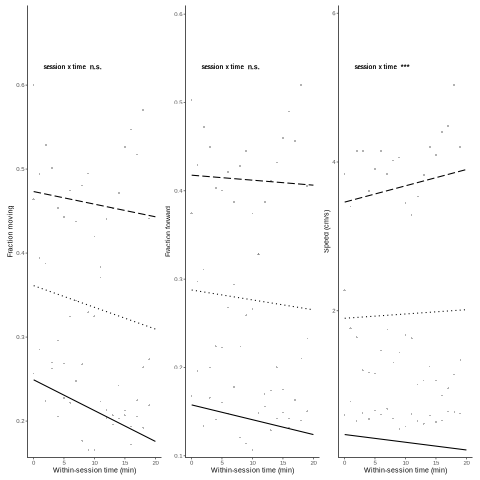

In [16]:
%%R -i hab_epoch_df_20min_pre -i fig_dir_str -o hab_epoch_stats_df -o hab_speed_simple_slopes_t_df

library(lme4)
library(lmerTest)
library(dplyr)
library(ggplot2)
library(patchwork)
library(emmeans)

# --------------------------------------------------
# Use final first-20-min epoch dataframe
# --------------------------------------------------

hab_epoch_df <- hab_epoch_df_20min_pre

# --------------------------------------------------
# Output folder
# --------------------------------------------------

out_dir <- fig_dir_str
dir.create(out_dir, showWarnings = FALSE, recursive = TRUE)

# --------------------------------------------------
# Prepare factors
# --------------------------------------------------

hab_epoch_df$animal <- factor(hab_epoch_df$animal)
hab_epoch_df$animal_day <- factor(hab_epoch_df$animal_day)

# --------------------------------------------------
# Primary outcomes
# --------------------------------------------------

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(hab_epoch_df)]

outcome_labels <- c(
  frac_moving = "Fraction moving",
  frac_forward = "Fraction forward",
  mean_speed_path_cms = "Speed (cm/s)"
)

# --------------------------------------------------
# Style maps
# --------------------------------------------------

shape_vals <- c(
  "Early exposure" = 16,   # circle
  "Mean exposure"  = 17,   # triangle
  "Late exposure"  = 15    # square
)

linetype_vals <- c(
  "Early exposure" = "solid",
  "Mean exposure"  = "dotted",
  "Late exposure"  = "longdash"
)

# --------------------------------------------------
# Helper functions
# --------------------------------------------------

  format_p <- function(p) {
  if (is.na(p)) {
    return("")
  } else if (p < 0.001) {
    return("***")
  } else if (p < 0.01) {
    return("**")
  } else if (p < 0.05) {
    return("*")
  } else {
    return("n.s.")
  }
}

predict_fixed_ci <- function(model, newdata) {
  fixed_formula <- formula(model, fixed.only = TRUE)
  X <- model.matrix(delete.response(terms(fixed_formula)), newdata)
  beta <- fixef(model)
  V <- vcov(model)

  fit <- as.numeric(X %*% beta)
  se <- sqrt(diag(X %*% V %*% t(X)))

  newdata$fit <- fit
  newdata$se <- se
  newdata$lower <- fit - 1.96 * se
  newdata$upper <- fit + 1.96 * se

  return(newdata)
}

theme_fig <- function() {
  theme_classic(base_size = 7) +
    theme(
      axis.title = element_text(size = 7),
      axis.text = element_text(size = 6),
      legend.title = element_text(size = 7),
      legend.text = element_text(size = 6),
      legend.position = "bottom",
      legend.key.width = unit(0.45, "in"),
      legend.key.height = unit(0.16, "in"),
      plot.title = element_blank(),
      plot.subtitle = element_blank(),
      plot.margin = margin(t = 0, r = 2, b = 0, l = 2)
      # plot.margin = margin(3, 4, 2, 2)
    )
}

# --------------------------------------------------
# Exposure levels for visualization
# --------------------------------------------------

# exposure_min <- min(hab_epoch_df$exposure_session, na.rm = TRUE)
# exposure_mean <- mean(hab_epoch_df$exposure_session, na.rm = TRUE)
# exposure_max <- max(hab_epoch_df$exposure_session, na.rm = TRUE)

exposure_early <- quantile(hab_epoch_df$exposure_session, 0.10, na.rm = TRUE)
exposure_mean  <- mean(hab_epoch_df$exposure_session, na.rm = TRUE)
exposure_late  <- quantile(hab_epoch_df$exposure_session, 0.90, na.rm = TRUE)

exposure_levels <- data.frame(
  exposure_session = c(exposure_early, exposure_mean, exposure_late),
  exposure_label = c("Early exposure", "Mean exposure", "Late exposure")
)

session_time_seq <- seq(
  min(hab_epoch_df$session_time_min, na.rm = TRUE),
  max(hab_epoch_df$session_time_min, na.rm = TRUE),
  length.out = 100
)

session_time_mean <- mean(hab_epoch_df$session_time_min, na.rm = TRUE)

# --------------------------------------------------
# Fit models and make plots
# --------------------------------------------------

model_list <- list()
stats_list <- list()
plot_list <- list()

for (outcome in primary_outcomes) {

  label_i <- unname(outcome_labels[outcome])

  cat("\n\n==============================\n")
  cat("Fitting:", outcome, "\n")
  cat("==============================\n")

  # -----------------------------
  # Fit LME
  # -----------------------------

  formula_text <- paste0(
    outcome,
    " ~ exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = hab_epoch_df,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  model_list[[outcome]] <- m

  # -----------------------------
  # Fixed-effect stats
  # -----------------------------

  coef_table <- as.data.frame(summary(m)$coefficients)

  tmp_stats <- data.frame(
    outcome = outcome,
    y_label = label_i,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    row.names = NULL
  )

  stats_list[[outcome]] <- tmp_stats

  # -----------------------------
  # Prediction data
  # -----------------------------

  pred_df <- expand.grid(
    session_time_min = session_time_seq,
    exposure_session = exposure_levels$exposure_session
  ) %>%
    left_join(exposure_levels, by = "exposure_session") %>%
    mutate(
      exposure_session_c = exposure_session - exposure_mean,
      session_time_10m_c = (session_time_min - session_time_mean) / 10
    )

  pred_df <- predict_fixed_ci(m, pred_df)

  pred_df$exposure_label <- factor(
    pred_df$exposure_label,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )

  # -----------------------------
  # Raw binned means for visual reference
  # -----------------------------

  q1 <- quantile(hab_epoch_df$exposure_session, 1/3, na.rm = TRUE)
  q2 <- quantile(hab_epoch_df$exposure_session, 2/3, na.rm = TRUE)

  raw_bin_df <- hab_epoch_df %>%
    mutate(
      session_time_bin = floor(session_time_min),
      exposure_label = case_when(
        exposure_session <= q1 ~ "Early exposure",
        exposure_session >= q2 ~ "Late exposure",
        TRUE ~ "Mean exposure"
      )
    ) %>%
    group_by(exposure_label, session_time_bin) %>%
    summarise(
      y_mean = mean(.data[[outcome]], na.rm = TRUE),
      .groups = "drop"
    )

  raw_bin_df$exposure_label <- factor(
    raw_bin_df$exposure_label,
    levels = c("Early exposure", "Mean exposure", "Late exposure")
  )



    # -----------------------------
  # Interaction p-value annotation
  # -----------------------------

  int_row <- tmp_stats[tmp_stats$term == "exposure_session_c:session_time_10m_c", ]

  interaction_label <- "session x time"

  p_label <- format_p(int_row$p)

  x_range <- range(hab_epoch_df$session_time_min, na.rm = TRUE)
  y_range <- range(c(raw_bin_df$y_mean, pred_df$fit), na.rm = TRUE)

  x_interaction <- x_range[1] + 0.08 * diff(x_range)
  x_pvalue      <- x_range[1] + 0.46 * diff(x_range)

  y_annot <- y_range[2] + 0.05 * diff(y_range)

  # -----------------------------
  # Plot
  # -----------------------------

  p <- ggplot() +

    # Binned raw means
    geom_point(
      data = raw_bin_df,
      aes(
        x = session_time_bin,
        y = y_mean,
        shape = exposure_label
      ),
      alpha = 0.55,
      size = 0.65,
      stroke = 0.25,
      colour = "grey45",
      show.legend = FALSE
    ) +

    # Model-predicted lines
    geom_line(
      data = pred_df,
      aes(
        x = session_time_min,
        y = fit,
        linetype = exposure_label
      ),
      linewidth = 0.5,
      colour = "black"
    ) +

    # "session x time"
    annotate(
      "text",
      x = x_interaction,
      y = y_annot,
      label = interaction_label,
      hjust = 0,
      vjust = 0.5,
      size = 2.2,
      fontface = "bold"
    ) +

    # p-value
    annotate(
      "text",
      x = x_pvalue,
      y = y_annot,
      label = p_label,
      hjust = 0,
      vjust = 0.5,
      size = 2.5,
      fontface = "bold"
    ) +

    scale_shape_manual(values = shape_vals, drop = FALSE) +
    scale_linetype_manual(values = linetype_vals, drop = FALSE) +

    scale_y_continuous(
      expand = expansion(mult = c(0.02, 0.16))
    ) +

    labs(
      x = "Within-session time (min)",
      y = label_i,
      linetype = "Exposure"
    ) +

    guides(
      shape = "none",
      linetype = guide_legend(
        title = "Exposure",
        nrow = 1,
        byrow = TRUE,
        override.aes = list(
          linewidth = 0.9,
          alpha = 1,
          colour = "black"
        )
      )
    ) +

    theme_fig()
    
  plot_list[[outcome]] <- p
}

hab_epoch_stats_df <- bind_rows(stats_list)

# --------------------------------------------------
# Simple slopes for speed with Satterthwaite df
# --------------------------------------------------

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(hab_epoch_df) + 1000,
  pbkrtest.limit = nrow(hab_epoch_df) + 1000
)

speed_model <- model_list[["mean_speed_path_cms"]]

exposure_c_values <- c(
  exposure_early - exposure_mean,
  0,
  exposure_late - exposure_mean
)

speed_trends <- emtrends(
  speed_model,
  ~ exposure_session_c,
  var = "session_time_10m_c",
  at = list(exposure_session_c = exposure_c_values),
  lmer.df = "satterthwaite"
)

hab_speed_simple_slopes_t_df <- as.data.frame(
  summary(
    speed_trends,
    infer = c(TRUE, TRUE),
    null = 0
  )
)

hab_speed_simple_slopes_t_df$exposure_label <- c(
  "Early exposure",
  "Mean exposure",
  "Late exposure"
)

print(hab_speed_simple_slopes_t_df)

# --------------------------------------------------
# Combine and save figure
# --------------------------------------------------

# p_combined <- plot_list[[primary_outcomes[1]]] +
#   plot_list[[primary_outcomes[2]]] +
#   plot_list[[primary_outcomes[3]]] +
#   plot_layout(nrow = 1, guides = "collect") &
#   theme(legend.position = "bottom")

# p_combined <- plot_list[[primary_outcomes[1]]] +
#   plot_list[[primary_outcomes[2]]] +
#   plot_list[[primary_outcomes[3]]] +
#   plot_layout(nrow = 1, guides = "collect") &
#   theme(
#     legend.position = "bottom",
#     legend.direction = "horizontal",

#     # smaller legend = more panel height
#     legend.text = element_text(size = 6),
#     legend.title = element_text(size = 6),
#     legend.key.width = unit(0.55, "cm"),
#     legend.key.height = unit(0.12, "cm"),

#     # move legend slightly down but keep it compact
#     legend.margin = margin(t = 0, r = 0, b = 0, l = 0),
#     legend.box.margin = margin(t = 2, r = 0, b = -3, l = 0),

#     # reduce outside plot margin
#     plot.margin = margin(t = 0, r = 2, b = 0, l = 2)
#   )

p_combined <- plot_list[[primary_outcomes[1]]] +
  plot_list[[primary_outcomes[2]]] +
  plot_list[[primary_outcomes[3]]] +
  plot_layout(nrow = 1) &
  theme(
    legend.position = "none"
  )

print(p_combined)

ggsave(
  filename = file.path(out_dir, "Fig1_within_session_habituation_3panel.pdf"),
  plot = p_combined,
  width = 7,
  height = 1.6
)



print(hab_epoch_stats_df)

## 15. Inspect final simple slopes for speed

The speed interaction is followed up using simple slopes of within-session time at early, mean, and late exposure. These slopes use Satterthwaite degrees of freedom so the manuscript can report `t(df)` values.

In [17]:
display(hab_speed_simple_slopes_t_df)

print(hab_speed_simple_slopes_t_df.columns.tolist())

,exposure_session_c,session_time_10m_c.trend,SE,df,lower.CL,upper.CL,t.ratio,p.value,exposure_label
1,-6.502338,-0.103948,0.052220,11468.873710,-0.206308,-0.001589,-1.990595,0.046549,Early exposure
2,0.000000,0.057860,0.031140,11465.300692,-0.003180,0.118899,1.858058,0.063186,Mean exposure
3,6.497662,0.219551,0.051129,11463.870045,0.119330,0.319772,4.294097,0.000018,Late exposure


['exposure_session_c', 'session_time_10m_c.trend', 'SE', 'df', 'lower.CL', 'upper.CL', 't.ratio', 'p.value', 'exposure_label']


In [ ]:
# Sessions in whole-session dataframe
whole_sessions = (
    hab_session_df[["animal", "date"]]
    .drop_duplicates()
    .assign(in_whole_session=True)
)

# Sessions in 20-min epoch dataframe
epoch_sessions_20min = (
    hab_epoch_df_20min_pre[["animal", "date"]]
    .drop_duplicates()
    .assign(in_epoch_20min=True)
)

session_compare = whole_sessions.merge(
    epoch_sessions_20min,
    on=["animal", "date"],
    how="outer"
)

session_compare["in_whole_session"] = session_compare["in_whole_session"].fillna(False)
session_compare["in_epoch_20min"] = session_compare["in_epoch_20min"].fillna(False)

missing_from_epoch = session_compare[
    (session_compare["in_whole_session"] == True) &
    (session_compare["in_epoch_20min"] == False)
]

display(missing_from_epoch)

,animal,date,in_whole_session,in_epoch_20min
71,NML_08,2026_02_06,True,False
80,NML_08,2026_02_15,True,False


In [29]:
for _, row in missing_from_epoch.iterrows():
    animal = row["animal"]
    date = row["date"]

    print("\nMissing session:", animal, date)

    tmp_all = encoder_epoch_df[
        (encoder_epoch_df["animal"].astype(str) == str(animal)) &
        (encoder_epoch_df["date"].astype(str) == str(date))
    ]

    print("Rows in encoder_epoch_df:", tmp_all.shape[0])

    if tmp_all.shape[0] > 0:
        print("Phase counts:")
        print(tmp_all["phase"].value_counts(dropna=False))

        time_cols = [c for c in tmp_all.columns if "time" in c.lower()]
        print("Time columns:", time_cols)

        if "session_time_min" in tmp_all.columns:
            print(tmp_all["session_time_min"].describe())
        elif "anchor_session_time_min" in tmp_all.columns:
            print(tmp_all["anchor_session_time_min"].describe())

        if "valid_window" in tmp_all.columns:
            print("valid_window counts:")
            print(tmp_all["valid_window"].value_counts(dropna=False))

        if "good_session_basic" in tmp_all.columns:
            print("good_session_basic counts:")
            print(tmp_all["good_session_basic"].value_counts(dropna=False))


Missing session: NML_08 2026_02_06
Rows in encoder_epoch_df: 0

Missing session: NML_08 2026_02_15
Rows in encoder_epoch_df: 492
Phase counts:
phase
habituation    492
Name: count, dtype: int64
Time columns: ['anchor_time_s', 'on_time_s', 'off_time_s', 'next_on_time_s', 'session_time_bin', 'anchor_session_time_min', 'anchor_rig_time_min', 'anchor_phase_time_min']
count    492.000000
mean      32.126302
std        5.925226
min       21.867293
25%       27.013611
50%       32.087608
75%       37.253129
max       42.373018
Name: anchor_session_time_min, dtype: float64
valid_window counts:
valid_window
True    492
Name: count, dtype: int64
good_session_basic counts:
good_session_basic
True    492
Name: count, dtype: int64


In [44]:
# --------------------------------------------------
# QC: whole-session habituation sample size
# --------------------------------------------------

qc_df = hab_session_df.copy()  # or hab_df.copy() if that is your final whole-session dataframe

# One row should correspond to one animal-session
session_cols = ["animal", "date"] if "date" in qc_df.columns else ["animal", "animal_day"]

hab_session_qc = (
    qc_df
    .drop_duplicates(session_cols)
    .groupby("animal")
    .size()
    .reset_index(name="n_habituation_sessions")
    .sort_values("animal")
)

display(hab_session_qc)

n_animals = hab_session_qc["animal"].nunique()
n_sessions = hab_session_qc["n_habituation_sessions"].sum()
min_sessions = hab_session_qc["n_habituation_sessions"].min()
max_sessions = hab_session_qc["n_habituation_sessions"].max()

print(f"Number of animals: {n_animals}")
print(f"Total habituation sessions: {n_sessions}")
print(f"Sessions per animal: {min_sessions}–{max_sessions}")

,animal,n_habituation_sessions
0,NML_04,16
1,NML_05,16
2,NML_06,16
3,NML_07,19
4,NML_08,19


Number of animals: 5
Total habituation sessions: 86
Sessions per animal: 16–19


In [45]:
# --------------------------------------------------
# QC: check whether there are duplicate animal-date rows
# --------------------------------------------------

duplicates = (
    qc_df
    .groupby(session_cols)
    .size()
    .reset_index(name="n_rows")
    .query("n_rows > 1")
)

print("Duplicate animal-session rows:")
display(duplicates)

Duplicate animal-session rows:


,animal,date,n_rows


Available anchors:
['LED_off', 'LED_off_mid', 'LED_on', 'LED_on_mid', 'pseudo_tone_off', 'pseudo_tone_on']
Using: NML_06 2025_12_27 habituation day 1
Using event_number: 3


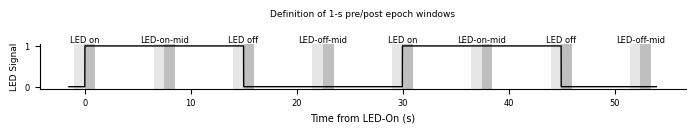

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

epoch_matrix_df = encoder_epoch_df.copy()

# --------------------------------------------------
# Settings
# --------------------------------------------------

phase = "habituation"
animal = "NML_06"          # change if needed
phase_day_number_good = 1  # change if needed
speed_key = "speed_net_cms"
pre_s = 1.0
post_s = 1.0

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

# --------------------------------------------------
# Helper: detect anchor names used in your dataframe
# --------------------------------------------------

def get_anchor_order_for_phase(epoch_matrix_df, phase):
    available = sorted(
        epoch_matrix_df.loc[
            epoch_matrix_df["phase"] == phase,
            "anchor_name"
        ].dropna().unique()
    )

    print("Available anchors:")
    print(available)

    candidate_orders = [
        ["led_on", "led_on_mid", "led_off", "led_off_mid"],
        ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"],
        ["air_on", "air_on_mid", "air_off", "air_off_mid"],
        ["Air_on", "Air_on_mid", "Air_off", "Air_off_mid"],
    ]

    for cand in candidate_orders:
        if all(a in available for a in cand):
            return cand

    raise ValueError(
        "Could not automatically detect the four anchor names. "
        "Check the printed available anchors and set anchor_order manually."
    )

anchor_order = get_anchor_order_for_phase(epoch_matrix_df, phase)


anchor_labels = {
    anchor_order[0]: "LED on",
    anchor_order[1]: "LED-on-mid",
    anchor_order[2]: "LED off",
    anchor_order[3]: "LED-off-mid",
}

# --------------------------------------------------
# Select one animal/day
# --------------------------------------------------

sub = epoch_matrix_df[
    (epoch_matrix_df["animal"] == animal) &
    (epoch_matrix_df["phase"] == phase) &
    # (epoch_matrix_df["phase_day_number_good"] == phase_day_number_good) &
    (epoch_matrix_df["anchor_name"].isin(anchor_order))
].copy()

if sub.empty:
    raise ValueError("No rows found for this animal / phase / day.")

dates = sorted(sub["date"].dropna().unique())
date = dates[0]
sub = sub[sub["date"] == date].copy()

print("Using:", animal, date, phase, "day", phase_day_number_good)

# --------------------------------------------------
# Pick one complete virtual cycle/event with all 4 anchors
# --------------------------------------------------

complete_events = (
    sub.groupby("event_number")["anchor_name"]
    .nunique()
    .reset_index(name="n_anchors")
)

complete_events = complete_events[complete_events["n_anchors"] == 4]

if complete_events.empty:
    raise ValueError("No event_number has all four anchors.")

event_number = complete_events.iloc[3]["event_number"]
event_number1 = complete_events.iloc[4]["event_number"]
print("Using event_number:", event_number)

ev = sub[sub["event_number"] == event_number].copy()
ev1 = sub[sub["event_number"] == event_number1].copy()

anchor_times = (
    ev[["anchor_name", "anchor_time_s"]]
    .drop_duplicates()
    .set_index("anchor_name")
    .loc[anchor_order]["anchor_time_s"]
)

anchor_times1 = (
    ev1[["anchor_name", "anchor_time_s"]]
    .drop_duplicates()
    .set_index("anchor_name")
    .loc[anchor_order]["anchor_time_s"]
)

# --------------------------------------------------
# Load raw net speed
# --------------------------------------------------

b = pdio.load_behavior_h5(
    animal,
    date,
    keys=[speed_key, "fs", "air_bin"]
)

speed = np.asarray(b[speed_key]).reshape(-1)
fs = float(np.asarray(b["fs"]).squeeze())
air_raw = np.asarray(b["air_bin"]).reshape(-1)

t = np.arange(len(speed)) / fs

# --------------------------------------------------
# Plot segment around this virtual cycle
# --------------------------------------------------

x_start = anchor_times.iloc[0] - 1.5
# x_end = anchor_times.iloc[-1] + 1.5
x_end = anchor_times1.iloc[-1] + 1.5

idx = (t >= x_start) & (t <= x_end)

fig, ax = plt.subplots(figsize=(7, 1.25))

# ax.plot(
#     t[idx] - anchor_times.iloc[0],
#     speed[idx],
#     linewidth=0.6,
#     color="black"
# )

ax.plot(
    t[idx] - anchor_times.iloc[0],
    air_raw[idx],
    linewidth=1,
    color="black",
    # linestyle="-.",
)

# ax.axvspan(
#     anchor_times.iloc[0]-anchor_times.iloc[0],
#     anchor_times.iloc[2]-anchor_times.iloc[0],
#     facecolor="0.50",
#     edgecolor="none",
#     alpha=1.0
# )

# ax.axvspan(
#     anchor_times1.iloc[0]-anchor_times.iloc[0],
#     anchor_times1.iloc[2]-anchor_times.iloc[0],
#     facecolor="0.50",
#     edgecolor="none",
#     alpha=1.0
# )


# Anchor windows
for anchor_name in anchor_order:
    at = anchor_times.loc[anchor_name]
    x0 = at - anchor_times.iloc[0]

    # Pre 1-s window
    ax.axvspan(
        x0 - pre_s,
        x0,
        facecolor="0.90",
        edgecolor="none",
        alpha=1.0
    )

    # Post 1-s window
    ax.axvspan(
        x0,
        x0 + post_s,
        facecolor="0.75",
        edgecolor="none",
        alpha=1.0
    )

    ax.text(
        x0,
        ax.get_ylim()[1],
        anchor_labels[anchor_name],
        ha="center",
        va="bottom",
        fontsize=6
    )

    at = anchor_times1.loc[anchor_name]
    x0 = at - anchor_times.iloc[0]

    # Pre 1-s window
    ax.axvspan(
        x0 - pre_s,
        x0,
        facecolor="0.90",
        edgecolor="none",
        alpha=1.0
    )

    # Post 1-s window
    ax.axvspan(
        x0,
        x0 + post_s,
        facecolor="0.75",
        edgecolor="none",
        alpha=1.0
    )

    # # Anchor line
    # ax.axvline(
    #     x0,
    #     linestyle="-",
    #     linewidth=0.8,
    #     color="black"
    # )

    ax.text(
        x0,
        ax.get_ylim()[1],
        anchor_labels[anchor_name],
        ha="center",
        va="bottom",
        fontsize=6
    )

# # Replot speed on top of shaded windows
# ax.plot(
#     t[idx] - anchor_times.iloc[0],
#     speed[idx],
#     linewidth=0.6,
#     color="black"
# )


# ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

ax.set_xlabel("Time from LED-On (s)", fontsize=7)
ax.set_ylabel("LED Signal", fontsize=6.5)
ax.tick_params(axis="both", labelsize=6)

ax.set_title(
    "Definition of 1-s pre/post epoch windows",
    fontsize=6.5,
    pad=20
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout(pad=0.4)

fig.savefig(
    fig_dir / "Figure_epoch_window_definition_raw_net_speed.pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     fig_dir / "Figure_epoch_window_definition_raw_net_speed.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()

In [19]:
t[idx]

array([144.763 , 144.7632, 144.7634, ..., 200.2094, 200.2096, 200.2098])

Available anchors:
['LED_off', 'LED_off_mid', 'LED_on', 'LED_on_mid', 'pseudo_tone_off', 'pseudo_tone_on']
2026_01_02
None


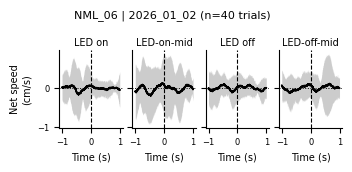

In [23]:
def plot_raw_net_speed_around_4anchors_one_animal(
    epoch_matrix_df,
    animal,
    phase="habituation",
    date = "2026_01_01",  # change if needed
    # phase_day_number_good=1,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_traces=None,
    show_individual_traces=False,
    fig_dir=None,
):
    """
    Plot raw net speed around the four virtual-cycle anchors for one animal/day.

    Thin gray lines = individual events/trials, optional
    Black line = mean
    Gray band = mean ± SD
    """

    anchor_order = get_anchor_order_for_phase(epoch_matrix_df, phase)

    anchor_labels = {
        anchor_order[0]: "LED on",
        anchor_order[1]: "LED-on-mid",
        anchor_order[2]: "LED off",
        anchor_order[3]: "LED-off-mid",
    }

    sub_all = epoch_matrix_df[
        (epoch_matrix_df["animal"] == animal) &
        (epoch_matrix_df["phase"] == phase) &
        # (epoch_matrix_df["phase_day_number_good"] == phase_day_number_good) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if sub_all.empty:
        raise ValueError("No rows found for this animal / phase / day.")

    # date = sorted(sub_all["date"].dropna().unique())[0]
    print(date)
    sub_all = sub_all[sub_all["date"] == date].copy()

    b = pdio.load_behavior_h5(
        animal,
        date,
        keys=[speed_key, "fs"]
    )

    speed = np.asarray(b[speed_key]).reshape(-1)
    fs = float(np.asarray(b["fs"]).squeeze())

    n_pre = int(round(pre_s * fs))
    n_post = int(round(post_s * fs))
    expected_n = n_pre + n_post

    rel_t = np.arange(-n_pre, n_post) / fs

    traces_by_anchor = {}

    for anchor_name in anchor_order:

        sub = sub_all[sub_all["anchor_name"] == anchor_name].copy()

        anchor_events = (
            sub[
                [
                    "event_number",
                    "anchor_name",
                    "anchor_time_s",
                ]
            ]
            .drop_duplicates()
            .sort_values("event_number")
            .reset_index(drop=True)
        )

        if max_traces is not None:
            anchor_events = anchor_events.iloc[:max_traces].copy()

        traces = []

        for _, ev in anchor_events.iterrows():

            anchor_time = ev["anchor_time_s"]

            if not np.isfinite(anchor_time):
                continue

            anchor_idx = int(round(anchor_time * fs))

            start_idx = anchor_idx - n_pre
            end_idx = anchor_idx + n_post

            if start_idx < 0 or end_idx > len(speed):
                continue

            trace = speed[start_idx:end_idx]

            if len(trace) == expected_n:
                traces.append(trace)

        if len(traces) > 0:
            traces_by_anchor[anchor_name] = np.vstack(traces)
        else:
            traces_by_anchor[anchor_name] = np.empty((0, expected_n))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(3.5, 1.5),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        traces = traces_by_anchor[anchor_name]

        if traces.shape[0] == 0:
            ax.text(0.5, 0.5, "No traces", ha="center", va="center", transform=ax.transAxes)
            continue

        mean_trace = np.nanmean(traces, axis=0)
        sd_trace = np.nanstd(traces, axis=0)

        if show_individual_traces:
            for tr in traces:
                ax.plot(rel_t, tr, color="0.75", linewidth=0.35, alpha=0.35)

        ax.fill_between(
            rel_t,
            mean_trace - sd_trace,
            mean_trace + sd_trace,
            color="0.80",
            linewidth=0
        )

        ax.plot(
            rel_t,
            mean_trace,
            color="black",
            linewidth=1.2
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
        ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)
        ax.set_xlabel("Time (s)", fontsize=7)
        ax.tick_params(axis="both", labelsize=6)

        # ax.text(
        #     0.96,
        #     0.05,
        #     f"n={traces.shape[0]}",
        #     transform=ax.transAxes,
        #     ha="right",
        #     va="bottom",
        #     fontsize=5.5
        # )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    fig.suptitle(
        f"{animal} | {date} (n={traces.shape[0]} trials)",
        fontsize=8,
        y=1.05
    )

    fig.tight_layout(pad=0.35)
    print(phase_day_number_good)
    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

        fname = f"Figure_raw_net_speed_4anchors_{animal}_{phase}_{date}"

        fig.savefig(fig_dir / f"{fname}.pdf", bbox_inches="tight")
        # fig.savefig(fig_dir / f"{fname}.png", dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "traces_by_anchor": traces_by_anchor,
        "time": rel_t,
        "animal": animal,
        "date": date,
        "phase": phase,
        # "phase_day_number_good": phase_day_number_good,
    }
phase_day_number_good = None
out = plot_raw_net_speed_around_4anchors_one_animal(
    epoch_matrix_df=epoch_matrix_df,
    animal="NML_06",
    phase="habituation",
    date="2026_01_02",
    # phase_day_number_good=1,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    show_individual_traces=False,
    fig_dir=fig_dir_str,
)

In [24]:
# --------------------------------------------------
# Binned epoch summaries for plotting dots
# --------------------------------------------------

outcome = "frac_moving"  # or "frac_forward", "mean_speed_path_cms"

df = hab_epoch_df_20min_pre.copy()

# Define exposure groups
q1 = df["exposure_session"].quantile(1/3)
q2 = df["exposure_session"].quantile(2/3)

df["exposure_label"] = np.select(
    [
        df["exposure_session"] <= q1,
        df["exposure_session"] >= q2,
    ],
    [
        "Early exposure",
        "Late exposure",
    ],
    default="Mean exposure"
)

# Define within-session 1-min bins
df["session_time_bin"] = np.floor(df["session_time_min"]).astype(int)

# Each row in raw_bin_df is one plotted dot
raw_bin_df = (
    df
    .groupby(["exposure_label", "session_time_bin"], observed=True)
    .agg(
        y_mean=(outcome, "mean"),
        n_epochs=(outcome, "count"),
    )
    .reset_index()
)

display(raw_bin_df.head())

,exposure_label,session_time_bin,y_mean,n_epochs
0,Early exposure,0,0.256736,84
1,Early exposure,1,0.285306,211
2,Early exposure,2,0.223539,224
3,Early exposure,3,0.262758,226
4,Early exposure,4,0.205300,229


,animal,n_sessions_LED_on,n_sessions_LED_on_mid,n_sessions_LED_off,n_sessions_LED_off_mid
0,NML_04,16,16,16,16
1,NML_05,16,16,16,16
2,NML_06,16,16,16,16
3,NML_07,19,19,17,17
4,NML_08,17,17,16,16


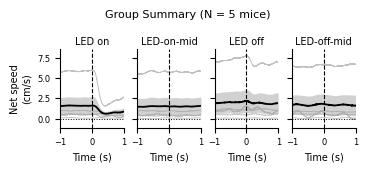

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def detect_anchor_order_for_phase(epoch_matrix_df, phase):
    available = sorted(
        epoch_matrix_df.loc[
            epoch_matrix_df["phase"].astype(str) == str(phase),
            "anchor_name"
        ].dropna().unique()
    )

    candidate_orders = [
        ["led_on", "led_on_mid", "led_off", "led_off_mid"],
        ["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"],
        ["air_on", "air_on_mid", "air_off", "air_off_mid"],
        ["air_onset", "air_on_mid", "air_offset", "air_off_mid"],
    ]

    for cand in candidate_orders:
        if all(a in available for a in cand):
            return cand

    print("Available anchors:")
    print(available)
    raise ValueError("Could not detect the four anchor names automatically.")


def plot_group_raw_net_speed_around_4anchors(
    epoch_matrix_df,
    phase="habituation",
    animals=None,
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    max_traces_per_session_anchor=None,
    show_individual_animals=True,
    fig_dir=None,
    save_prefix="Fig_group_raw_net_speed_4anchors",
):
    """
    Group raw net-speed traces around the four timing anchors.

    Averaging hierarchy:
      event traces -> session mean -> animal mean -> group mean ± SEM

    This avoids treating event windows as independent animals.
    """

    # --------------------------------------------------
    # Output folder
    # --------------------------------------------------

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

    # --------------------------------------------------
    # Anchor setup
    # --------------------------------------------------

    anchor_order = detect_anchor_order_for_phase(epoch_matrix_df, phase)

    anchor_labels = {
        anchor_order[0]: "LED on" if "led" in anchor_order[0].lower() else "Air on",
        anchor_order[1]: "LED-on-mid" if "led" in anchor_order[1].lower() else "Air-on\nmidpoint",
        anchor_order[2]: "LED off" if "led" in anchor_order[2].lower() else "Air off",
        anchor_order[3]: "LED-off-mid" if "led" in anchor_order[3].lower() else "Air-off\nmidpoint",
    }

    # --------------------------------------------------
    # Filter dataframe
    # --------------------------------------------------

    df = epoch_matrix_df[
        (epoch_matrix_df["phase"].astype(str) == str(phase)) &
        (epoch_matrix_df["anchor_name"].isin(anchor_order))
    ].copy()

    if animals is None:
        animals = sorted(df["animal"].dropna().unique())
    else:
        animals = list(animals)
        df = df[df["animal"].isin(animals)].copy()

    if max_session_time_min is not None:
        df = df[df["anchor_time_s"] <= max_session_time_min * 60].copy()

    if df.empty:
        raise ValueError("No rows left after filtering.")

    # --------------------------------------------------
    # Sampling settings
    # --------------------------------------------------

    animal_mean_traces = {a: [] for a in anchor_order}
    animal_ids_used = {a: [] for a in anchor_order}
    session_counts = []

    # --------------------------------------------------
    # Extract traces animal by animal
    # --------------------------------------------------

    for animal in animals:

        df_animal = df[df["animal"] == animal].copy()

        if df_animal.empty:
            continue

        # session-level means for this animal
        session_mean_by_anchor = {a: [] for a in anchor_order}

        for date, df_session in df_animal.groupby("date", observed=True):

            # Load raw behavior once per session
            try:
                b = pdio.load_behavior_h5(
                    animal,
                    date,
                    keys=[speed_key, "fs"]
                )
            except Exception as e:
                print(f"Skipping {animal} {date}: could not load H5. Error: {e}")
                continue

            speed = np.asarray(b[speed_key]).reshape(-1)
            fs = float(np.asarray(b["fs"]).squeeze())

            n_pre = int(round(pre_s * fs))
            n_post = int(round(post_s * fs))
            expected_n = n_pre + n_post
            rel_t = np.arange(-n_pre, n_post) / fs

            for anchor_name in anchor_order:

                sub = df_session[df_session["anchor_name"] == anchor_name].copy()

                if sub.empty:
                    continue

                anchor_events = (
                    sub[
                        [
                            "event_number",
                            "anchor_name",
                            "anchor_time_s",
                        ]
                    ]
                    .drop_duplicates()
                    .sort_values("event_number")
                    .reset_index(drop=True)
                )

                if max_traces_per_session_anchor is not None:
                    anchor_events = anchor_events.iloc[:max_traces_per_session_anchor].copy()

                traces = []

                for _, ev in anchor_events.iterrows():

                    anchor_time = ev["anchor_time_s"]

                    if not np.isfinite(anchor_time):
                        continue

                    anchor_idx = int(round(anchor_time * fs))
                    start_idx = anchor_idx - n_pre
                    end_idx = anchor_idx + n_post

                    if start_idx < 0 or end_idx > len(speed):
                        continue

                    trace = speed[start_idx:end_idx]

                    if len(trace) == expected_n:
                        traces.append(trace)

                if len(traces) > 0:
                    traces = np.vstack(traces)
                    session_mean = np.nanmean(traces, axis=0)
                    session_mean_by_anchor[anchor_name].append(session_mean)

        # Average session means within animal
        for anchor_name in anchor_order:

            if len(session_mean_by_anchor[anchor_name]) == 0:
                continue

            session_means = np.vstack(session_mean_by_anchor[anchor_name])
            animal_mean = np.nanmean(session_means, axis=0)

            animal_mean_traces[anchor_name].append(animal_mean)
            animal_ids_used[anchor_name].append(animal)

        session_counts.append({
            "animal": animal,
            **{
                f"n_sessions_{anchor_name}": len(session_mean_by_anchor[anchor_name])
                for anchor_name in anchor_order
            }
        })

    session_counts_df = pd.DataFrame(session_counts)
    display(session_counts_df)

    # --------------------------------------------------
    # Convert to arrays and compute group mean ± SEM
    # --------------------------------------------------

    group_summary = {}

    for anchor_name in anchor_order:

        if len(animal_mean_traces[anchor_name]) == 0:
            group_summary[anchor_name] = None
            continue

        arr = np.vstack(animal_mean_traces[anchor_name])

        group_mean = np.nanmean(arr, axis=0)
        group_sem = np.nanstd(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])

        group_summary[anchor_name] = {
            "animal_mean_traces": arr,
            "group_mean": group_mean,
            "group_sem": group_sem,
            "n_animals": arr.shape[0],
            "animal_ids": animal_ids_used[anchor_name],
        }

    # --------------------------------------------------
    # Common y-limits
    # --------------------------------------------------

    all_group_values = []

    for anchor_name in anchor_order:
        s = group_summary[anchor_name]
        if s is None:
            continue
        all_group_values.append(s["animal_mean_traces"])

    all_group_values = np.vstack(all_group_values)

    y_low, y_high = np.nanpercentile(all_group_values, [1, 99])
    y_pad = 0.15 * (y_high - y_low)
    y_lim = (y_low - y_pad, y_high + y_pad)

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    fig, axes = plt.subplots(
        1,
        4,
        figsize=(3.5, 1.5),
        sharex=True,
        sharey=True
    )

    for ax, anchor_name in zip(axes, anchor_order):

        s = group_summary[anchor_name]

        if s is None:
            ax.text(
                0.5,
                0.5,
                "No data",
                transform=ax.transAxes,
                ha="center",
                va="center",
                fontsize=7
            )
            continue

        animal_arr = s["animal_mean_traces"]
        group_mean = s["group_mean"]
        group_sem = s["group_sem"]

        if show_individual_animals:
            for tr in animal_arr:
                ax.plot(
                    rel_t,
                    tr,
                    color="0.65",
                    linewidth=0.7,
                    alpha=0.7
                )

        ax.fill_between(
            rel_t,
            group_mean - group_sem,
            group_mean + group_sem,
            color="0.80",
            linewidth=0,
            alpha=0.9
        )

        ax.plot(
            rel_t,
            group_mean,
            color="black",
            linewidth=1.3
        )

        ax.axvline(0, linestyle="--", linewidth=0.8, color="black")
        ax.axhline(0, linestyle=":", linewidth=0.7, color="black")

        ax.set_title(anchor_labels[anchor_name], fontsize=7, pad=3)
        ax.set_xlabel("Time (s)", fontsize=7)
        ax.tick_params(axis="both", labelsize=6)
        ax.set_xlim(-pre_s, post_s)
        ax.set_ylim(y_lim)

        # ax.text(
        #     0.96,
        #     0.02,
        #     f"N={s['n_animals']}",
        #     transform=ax.transAxes,
        #     ha="right",
        #     va="bottom",
        #     fontsize=5.5
        # )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0].set_ylabel("Net speed\n(cm/s)", fontsize=7)

    fig.suptitle(
        f"Group Summary (N = 5 mice)",
        fontsize=8,
        y=1.05
    )

    fig.tight_layout(pad=0.35)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------

    if fig_dir is not None:
        fname = f"{save_prefix}_{phase}"

        fig.savefig(
            fig_dir / f"{fname}.pdf",
            bbox_inches="tight"
        )

        fig.savefig(
            fig_dir / f"{fname}.png",
            dpi=600,
            bbox_inches="tight"
        )

    plt.show()

    return {
        "fig": fig,
        "axes": axes,
        "rel_t": rel_t,
        "group_summary": group_summary,
        "session_counts_df": session_counts_df,
        "anchor_order": anchor_order,
    }

out_group = plot_group_raw_net_speed_around_4anchors(
    epoch_matrix_df=epoch_matrix_df,
    phase="habituation",
    animals=None,                    # or ["NML_04", "NML_05", ...]
    speed_key="speed_net_cms",
    pre_s=1.0,
    post_s=1.0,
    max_session_time_min=20,
    show_individual_animals=True,
    fig_dir=fig_dir_str,
)

In [30]:
# --------------------------------------------------
# QC: why do LED anchor counts differ?
# --------------------------------------------------

qc = epoch_matrix_df.copy()

qc = qc[
    (qc["phase"].astype(str) == "habituation") &
    (qc["anchor_name"].isin(["LED_on", "LED_on_mid", "LED_off", "LED_off_mid"]))
].copy()

# Restrict to first 20 min if matching the analysis
qc_20 = qc[qc["anchor_session_time_min"] <= 20].copy()

print("All LED rows in habituation:", qc.shape)
print("After 20-min restriction:", qc_20.shape)

print("\nCounts before valid-window filtering:")
display(
    qc_20
    .groupby(["anchor_name", "window_position"], observed=True)
    .size()
    .reset_index(name="n")
)

print("\nCounts by valid_window:")
display(
    qc_20
    .groupby(["anchor_name", "window_position", "valid_window"], observed=True)
    .size()
    .reset_index(name="n")
)

print("\nInvalid reasons:")
display(
    qc_20
    .loc[qc_20["valid_window"] == False]
    .groupby(["anchor_name", "window_position", "invalid_reason"], observed=True)
    .size()
    .reset_index(name="n")
    .sort_values(["anchor_name", "window_position", "n"], ascending=[True, True, False])
)

All LED rows in habituation: (25476, 59)
After 20-min restriction: (23092, 59)

Counts before valid-window filtering:


,anchor_name,window_position,n
0,LED_off,post,2869
1,LED_off,pre,2869
2,LED_off_mid,post,2855
3,LED_off_mid,pre,2855
4,LED_on,post,2921
5,LED_on,pre,2921
6,LED_on_mid,post,2901
7,LED_on_mid,pre,2901



Counts by valid_window:


,anchor_name,window_position,valid_window,n
0,LED_off,post,True,2869
1,LED_off,pre,True,2869
2,LED_off_mid,post,True,2855
3,LED_off_mid,pre,True,2855
4,LED_on,post,True,2921
5,LED_on,pre,True,2921
6,LED_on_mid,post,True,2901
7,LED_on_mid,pre,True,2901



Invalid reasons:


,anchor_name,window_position,invalid_reason,n


In [5]:
import numpy as np
import pandas as pd

# --------------------------------------------------
# Build LED pre/post dataframe directly from epoch_matrix_df
# --------------------------------------------------
epoch_matrix_df = encoder_epoch_df.copy()

src = epoch_matrix_df.copy()

# --------------------------------------------------
# Filter to habituation
# --------------------------------------------------

led_prepost_df = src[
    src["phase"].astype(str).str.lower().eq("habituation")
].copy()

print("After phase filter:", led_prepost_df.shape)

# --------------------------------------------------
# Keep good/valid windows if these columns exist
# --------------------------------------------------

if "good_session_basic" in led_prepost_df.columns:
    led_prepost_df = led_prepost_df[
        led_prepost_df["good_session_basic"] == True
    ].copy()

if "valid_window" in led_prepost_df.columns:
    led_prepost_df = led_prepost_df[
        led_prepost_df["valid_window"] == True
    ].copy()

print("After good/valid filter:", led_prepost_df.shape)

# --------------------------------------------------
# Restrict to first 20 min, matching within-session analysis
# --------------------------------------------------

if "anchor_session_time_min" in led_prepost_df.columns:
    led_prepost_df = led_prepost_df[
        led_prepost_df["anchor_session_time_min"] <= 20
    ].copy()
elif "session_time_min" in led_prepost_df.columns:
    led_prepost_df = led_prepost_df[
        led_prepost_df["session_time_min"] <= 20
    ].copy()
else:
    raise ValueError("Need anchor_session_time_min or session_time_min.")

print("After 20-min filter:", led_prepost_df.shape)

# --------------------------------------------------
# Keep the four LED-defined anchors
# --------------------------------------------------

anchor_order = [
    "LED_on",
    "LED_on_mid",
    "LED_off",
    "LED_off_mid",
]

led_prepost_df = led_prepost_df[
    led_prepost_df["anchor_name"].isin(anchor_order)
].copy()

print("After LED anchor filter:", led_prepost_df.shape)

# --------------------------------------------------
# Keep pre/post windows
# --------------------------------------------------

window_order = ["pre", "post"]

led_prepost_df["window_position"] = (
    led_prepost_df["window_position"]
    .astype(str)
    .str.lower()
    .str.strip()
)

led_prepost_df = led_prepost_df[
    led_prepost_df["window_position"].isin(window_order)
].copy()

print("After pre/post filter:", led_prepost_df.shape)

# --------------------------------------------------
# Create animal-day/session ID
# --------------------------------------------------

if "animal_day" not in led_prepost_df.columns:
    led_prepost_df["animal_day"] = (
        led_prepost_df["animal"].astype(str) + ":" +
        led_prepost_df["date"].astype(str)
    )

# --------------------------------------------------
# Create event ID
# --------------------------------------------------

led_prepost_df["event_id"] = (
    led_prepost_df["animal_day"].astype(str) +
    ":event_" +
    led_prepost_df["event_number"].astype(str)
)

# --------------------------------------------------
# Exposure session predictor
# --------------------------------------------------
# In epoch_matrix_df, phase_session_number is the best available repeated-exposure index.

if "exposure_session" not in led_prepost_df.columns:
    if "phase_session_number" in led_prepost_df.columns:
        led_prepost_df["exposure_session"] = led_prepost_df["phase_session_number"]
    elif "phase_day_from_date" in led_prepost_df.columns:
        led_prepost_df["exposure_session"] = led_prepost_df["phase_day_from_date"]
    else:
        raise ValueError("Need phase_session_number or phase_day_from_date.")

led_prepost_df["exposure_session_c"] = (
    led_prepost_df["exposure_session"] -
    led_prepost_df["exposure_session"].mean()
)

# --------------------------------------------------
# Within-session time predictor
# --------------------------------------------------

if "anchor_session_time_min" in led_prepost_df.columns:
    session_time_min_for_model = led_prepost_df["anchor_session_time_min"].astype(float)
elif "session_time_min" in led_prepost_df.columns:
    session_time_min_for_model = led_prepost_df["session_time_min"].astype(float)
else:
    raise ValueError("Need anchor_session_time_min or session_time_min.")

led_prepost_df["session_time_10m_c"] = (
    session_time_min_for_model -
    session_time_min_for_model.mean()
) / 10.0

# --------------------------------------------------
# Make ordered categorical columns
# --------------------------------------------------

led_prepost_df["anchor_name"] = pd.Categorical(
    led_prepost_df["anchor_name"],
    categories=anchor_order,
    ordered=True,
)

led_prepost_df["window_position"] = pd.Categorical(
    led_prepost_df["window_position"],
    categories=window_order,
    ordered=True,
)

# --------------------------------------------------
# Outcomes
# --------------------------------------------------

candidate_outcomes = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
    "mean_speed_net_cms",
]

available_outcomes = [
    c for c in candidate_outcomes
    if c in led_prepost_df.columns
]

print("Available outcomes:", available_outcomes)

required_cols = [
    "animal",
    "animal_day",
    "event_id",
    "anchor_name",
    "window_position",
    "exposure_session",
    "exposure_session_c",
    "session_time_10m_c",
] + available_outcomes

led_prepost_df = led_prepost_df[required_cols].copy()

# --------------------------------------------------
# Final QC
# --------------------------------------------------

print("\nFinal led_prepost_df shape:", led_prepost_df.shape)
print("n animals:", led_prepost_df["animal"].nunique())
print("n animal-days:", led_prepost_df["animal_day"].nunique())
print("n events:", led_prepost_df["event_id"].nunique())

display(
    led_prepost_df
    .groupby(["anchor_name", "window_position"], observed=True)
    .size()
    .reset_index(name="n")
)

display(led_prepost_df.head())

After phase filter: (38237, 59)
After good/valid filter: (38237, 59)
After 20-min filter: (34766, 59)
After LED anchor filter: (23092, 59)
After pre/post filter: (23092, 59)
Available outcomes: ['frac_moving', 'frac_forward', 'mean_speed_path_cms', 'mean_speed_net_cms']

Final led_prepost_df shape: (23092, 12)
n animals: 5
n animal-days: 84
n events: 2921


,anchor_name,window_position,n
0,LED_on,pre,2921
1,LED_on,post,2921
2,LED_on_mid,pre,2901
3,LED_on_mid,post,2901
4,LED_off,pre,2869
5,LED_off,post,2869
6,LED_off_mid,pre,2855
7,LED_off_mid,post,2855


,animal,animal_day,event_id,anchor_name,window_position,exposure_session,exposure_session_c,session_time_10m_c,frac_moving,frac_forward,mean_speed_path_cms,mean_speed_net_cms
42362,NML_04,NML_04:2025_12_27,NML_04:2025_12_27:event_0,LED_off_mid,post,1,-8.502338,-0.867721,0.7754,0.4378,2.342573,7.829352e-01
42363,NML_04,NML_04:2025_12_27,NML_04:2025_12_27:event_0,LED_off_mid,pre,1,-8.502338,-0.867721,0.8246,0.4530,1.504747,4.080552e-01
42364,NML_04,NML_04:2025_12_27,NML_04:2025_12_27:event_0,LED_off,post,1,-8.502338,-0.880208,0.0000,0.0000,0.100531,5.684342e-18
42365,NML_04,NML_04:2025_12_27,NML_04:2025_12_27:event_0,LED_off,pre,1,-8.502338,-0.880208,0.3184,0.2738,0.457567,2.585154e-01
42366,NML_04,NML_04:2025_12_27,NML_04:2025_12_27:event_0,LED_on_mid,post,1,-8.502338,-0.892695,0.0000,0.0000,0.000000,0.000000e+00


In [6]:
# --------------------------------------------------
# Add event-anchor ID for paired pre/post windows
# --------------------------------------------------
# This identifies each exact anchor occurrence:
# e.g., one LED_on event within one virtual cycle/session.
# The pre and post windows around that anchor share the same event_anchor_id.

led_prepost_df = led_prepost_df.copy()

led_prepost_df["event_anchor_id"] = (
    led_prepost_df["event_id"].astype(str) + ":" +
    led_prepost_df["anchor_name"].astype(str)
)

print("led_prepost_df shape:", led_prepost_df.shape)
print("n animals:", led_prepost_df["animal"].nunique())
print("n animal-days:", led_prepost_df["animal_day"].nunique())
print("n events:", led_prepost_df["event_id"].nunique())
print("n event-anchor IDs:", led_prepost_df["event_anchor_id"].nunique())

display(
    led_prepost_df
    .groupby(["anchor_name", "window_position"], observed=True)
    .size()
    .reset_index(name="n")
)

display(
    led_prepost_df
    .groupby("event_anchor_id", observed=True)
    .size()
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "rows_per_event_anchor", 0: "n_event_anchors"})
)

led_prepost_df shape: (23092, 13)
n animals: 5
n animal-days: 84
n events: 2921
n event-anchor IDs: 11546


,anchor_name,window_position,n
0,LED_on,pre,2921
1,LED_on,post,2921
2,LED_on_mid,pre,2901
3,LED_on_mid,post,2901
4,LED_off,pre,2869
5,LED_off,post,2869
6,LED_off_mid,pre,2855
7,LED_off_mid,post,2855


,rows_per_event_anchor,count
0,2,11546


In [9]:
%load_ext rpy2.ipython

In [7]:
%%R -i led_prepost_df -o led_anchor_refined_stats_df -o led_anchor_refined_contrasts_df -o led_anchor_refined_emm_df -o led_anchor_refined_model_info_df -o led_anchor_refined_anova_df

library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

led_prepost_df$animal <- factor(led_prepost_df$animal)
led_prepost_df$animal_day <- factor(led_prepost_df$animal_day)
led_prepost_df$event_id <- factor(led_prepost_df$event_id)
led_prepost_df$event_anchor_id <- factor(led_prepost_df$event_anchor_id)

led_prepost_df$anchor_name <- factor(
  led_prepost_df$anchor_name,
  levels = c(
    "LED_on",
    "LED_on_mid",
    "LED_off",
    "LED_off_mid"
  ),
  ordered = FALSE
)

led_prepost_df$window_position <- factor(
  led_prepost_df$window_position,
  levels = c("pre", "post"),
  ordered = FALSE
)

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms",
  "mean_speed_net_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(led_prepost_df)]

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(led_prepost_df) + 1000,
  pbkrtest.limit = nrow(led_prepost_df) + 1000
)

# --------------------------------------------------
# Fit refined models
# --------------------------------------------------

stats_list <- list()
emm_list <- list()
contrast_list <- list()
model_info_list <- list()
anova_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting refined model for:", outcome, "\n")
  cat("==============================\n")

  df_i <- led_prepost_df %>%
    filter(
      !is.na(.data[[outcome]]),
      !is.na(anchor_name),
      !is.na(window_position),
      !is.na(exposure_session_c),
      !is.na(session_time_10m_c),
      !is.na(animal),
      !is.na(animal_day),
      !is.na(event_id),
      !is.na(event_anchor_id)
    )

  cat("n rows:", nrow(df_i), "\n")
  print(table(df_i$anchor_name, df_i$window_position))

  formula_text <- paste0(
    outcome,
    " ~ anchor_name * window_position + ",
    "exposure_session_c + session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | event_id) + (1 | event_anchor_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = df_i,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  anova_table <- as.data.frame(anova(m, type = 3))
  anova_table$effect <- rownames(anova_table)
  anova_table$outcome <- outcome
  anova_table$singular_fit <- isSingular(m, tol = 1e-4)
  rownames(anova_table) <- NULL

  anova_list[[outcome]] <- anova_table  

  # --------------------------------------------------
  # Model diagnostics/info
  # --------------------------------------------------

  model_info_list[[outcome]] <- data.frame(
    outcome = outcome,
    n_obs = nobs(m),
    is_singular = isSingular(m, tol = 1e-4),
    logLik = as.numeric(logLik(m)),
    AIC = AIC(m),
    BIC = BIC(m),
    row.names = NULL
  )

  cat("Singular fit:", isSingular(m, tol = 1e-4), "\n")

  # --------------------------------------------------
  # Fixed effects
  # --------------------------------------------------

  coef_table <- as.data.frame(summary(m)$coefficients)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    singular_fit = isSingular(m, tol = 1e-4),
    row.names = NULL
  )

  # --------------------------------------------------
  # Estimated marginal means
  # --------------------------------------------------

  emm <- emmeans(
    m,
    ~ window_position | anchor_name,
    at = list(
      exposure_session_c = 0,
      session_time_10m_c = 0
    ),
    lmer.df = "satterthwaite"
  )

  emm_df <- as.data.frame(summary(emm, infer = c(TRUE, TRUE)))
  emm_df$outcome <- outcome
  emm_df$singular_fit <- isSingular(m, tol = 1e-4)
  emm_list[[outcome]] <- emm_df

  # --------------------------------------------------
  # Planned contrast: post minus pre within each anchor
  # --------------------------------------------------

  ctr <- contrast(
    emm,
    method = list(
      "post_minus_pre" = c(-1, 1)
    ),
    by = "anchor_name",
    adjust = "none"
  )

  ctr_df <- as.data.frame(summary(ctr, infer = c(TRUE, TRUE)))
  ctr_df$outcome <- outcome
  ctr_df$singular_fit <- isSingular(m, tol = 1e-4)
  contrast_list[[outcome]] <- ctr_df
}

led_anchor_refined_stats_df <- bind_rows(stats_list)
led_anchor_refined_emm_df <- bind_rows(emm_list)
led_anchor_refined_contrasts_df <- bind_rows(contrast_list)
led_anchor_refined_model_info_df <- bind_rows(model_info_list)
led_anchor_refined_anova_df <- bind_rows(anova_list)

cat("\n\n===== Refined model info =====\n")
print(led_anchor_refined_model_info_df)

cat("\n\n===== Refined planned contrasts =====\n")
print(led_anchor_refined_contrasts_df)

cat("\n\n===== Refined model stats =====\n")
print(led_anchor_refined_stats_df)

cat("\n\n===== Refined model emm =====\n")
print(led_anchor_refined_emm_df)


R[write to console]: Loading required package: Matrix

R[write to console]: 
Attaching package: ‘lmerTest’


R[write to console]: The following object is masked from ‘package:lme4’:

    lmer


R[write to console]: The following object is masked from ‘package:stats’:

    step


R[write to console]: 
Attaching package: ‘dplyr’


R[write to console]: The following objects are masked from ‘package:stats’:

    filter, lag


R[write to console]: The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


R[write to console]: Welcome to emmeans.
Caution: You lose important information if you filter this package's results.
See '? untidy'





Fitting refined model for: frac_moving 
n rows: 23092 
             
               pre post
  LED_on      2921 2921
  LED_on_mid  2901 2901
  LED_off     2869 2869
  LED_off_mid 2855 2855
Singular fit: FALSE 


Fitting refined model for: frac_forward 
n rows: 23092 
             
               pre post
  LED_on      2921 2921
  LED_on_mid  2901 2901
  LED_off     2869 2869
  LED_off_mid 2855 2855
Singular fit: FALSE 


Fitting refined model for: mean_speed_path_cms 
n rows: 23092 
             
               pre post
  LED_on      2921 2921
  LED_on_mid  2901 2901
  LED_off     2869 2869
  LED_off_mid 2855 2855
Singular fit: FALSE 


Fitting refined model for: mean_speed_net_cms 
n rows: 23092 
             
               pre post
  LED_on      2921 2921
  LED_on_mid  2901 2901
  LED_off     2869 2869
  LED_off_mid 2855 2855
Singular fit: FALSE 


===== Refined model info =====
              outcome n_obs is_singular     logLik       AIC       BIC
1         frac_moving 23092     

In [11]:
display(led_anchor_refined_anova_df)

led_anchor_refined_interaction_anova_df = (
    led_anchor_refined_anova_df
    .query("effect == 'anchor_name:window_position'")
    .reset_index(drop=True)
)

display(led_anchor_refined_interaction_anova_df)

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),effect,outcome,singular_fit
1,0.407518,0.135839,3,8669.513066,5.291762,1.210481e-03,anchor_name,frac_moving,False
2,0.040296,0.040296,1,11546.000283,1.569771,2.102657e-01,window_position,frac_moving,False
3,1.106583,1.106583,1,74.236254,43.108086,6.201602e-09,exposure_session_c,frac_moving,False
4,0.463688,0.463688,1,2894.207835,18.063456,2.204168e-05,session_time_10m_c,frac_moving,False
5,0.163728,0.054576,3,11546.000286,2.126067,9.465336e-02,anchor_name:window_position,frac_moving,False
6,0.632304,0.210768,3,8669.227609,11.018689,3.228335e-07,anchor_name,frac_forward,False
7,0.142946,0.142946,1,11546.000263,7.473028,6.272556e-03,window_position,frac_forward,False
8,0.971988,0.971988,1,76.510623,50.814299,4.879719e-10,exposure_session_c,frac_forward,False
9,0.070415,0.070415,1,2897.726690,3.681208,5.512709e-02,session_time_10m_c,frac_forward,False
10,0.692977,0.230992,3,11546.000263,12.075999,6.884014e-08,anchor_name:window_position,frac_forward,False


,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),effect,outcome,singular_fit
0,0.163728,0.054576,3,11546.000286,2.126067,9.465336e-02,anchor_name:window_position,frac_moving,False
1,0.692977,0.230992,3,11546.000263,12.075999,6.884014e-08,anchor_name:window_position,frac_forward,False
2,496.453677,165.484559,3,11545.998415,149.257841,6.690702e-95,anchor_name:window_position,mean_speed_path_cms,False
3,663.582232,221.194077,3,11546.002780,154.680595,2.719406e-98,anchor_name:window_position,mean_speed_net_cms,False


In [12]:
import pandas as pd

# Make sure p is numeric
led_anchor_refined_stats_df["p"] = pd.to_numeric(
    led_anchor_refined_stats_df["p"],
    errors="coerce"
)

# Show full refined model stats
display(led_anchor_refined_stats_df)

# Save significant rows as a new Python dataframe
led_anchor_refined_stats_sig_df = (
    led_anchor_refined_stats_df
    .query("p < 0.05")
    .sort_values(["outcome", "p"])
    .reset_index(drop=True)
)

# Show only p < 0.05 rows
display(led_anchor_refined_stats_sig_df)

,outcome,term,beta,se,df,t,p,n_obs,singular_fit
1,frac_moving,(Intercept),0.334659,0.085312,5.035561,3.922747,1.099686e-02,23092,False
2,frac_moving,anchor_nameLED_on_mid,-0.010100,0.007619,11755.155018,-1.325727,1.849560e-01,23092,False
3,frac_moving,anchor_nameLED_off,0.012471,0.007644,11785.089605,1.631405,1.028317e-01,23092,False
4,frac_moving,anchor_nameLED_off_mid,-0.003958,0.007656,11805.096964,-0.517040,6.051381e-01,23092,False
5,frac_moving,window_positionpost,-0.002975,0.004192,11546.000287,-0.709670,4.779233e-01,23092,False
6,frac_moving,exposure_session_c,0.018180,0.002769,74.236254,6.565675,6.201602e-09,23092,False
7,frac_moving,session_time_10m_c,-0.027361,0.006438,2894.207835,-4.250113,2.204168e-05,23092,False
8,frac_moving,anchor_nameLED_on_mid:window_positionpost,0.007533,0.005939,11546.000287,1.268402,2.046799e-01,23092,False
9,frac_moving,anchor_nameLED_off:window_positionpost,0.013448,0.005956,11546.000287,2.258069,2.395993e-02,23092,False
10,frac_moving,anchor_nameLED_off_mid:window_positionpost,0.001488,0.005963,11546.000288,0.249452,8.030156e-01,23092,False


,outcome,term,beta,se,df,t,p,n_obs,singular_fit
0,frac_forward,window_positionpost,-0.023488,0.003619,11546.000264,-6.490272,8.918961e-11,23092,False
1,frac_forward,exposure_session_c,0.020208,0.002835,76.510623,7.128415,4.879719e-10,23092,False
2,frac_forward,anchor_nameLED_on_mid:window_positionpost,0.027380,0.005127,11546.000264,5.340591,9.440269e-08,23092,False
3,frac_forward,anchor_nameLED_off:window_positionpost,0.025359,0.005141,11546.000264,4.932607,8.226964e-07,23092,False
4,frac_forward,anchor_nameLED_off_mid:window_positionpost,0.021308,0.005148,11546.000262,4.139508,3.505245e-05,23092,False
5,frac_forward,anchor_nameLED_off,0.018300,0.006453,11948.688308,2.836008,4.575813e-03,23092,False
6,frac_forward,(Intercept),0.273349,0.084847,5.027112,3.221677,2.324209e-02,23092,False
7,frac_moving,exposure_session_c,0.018180,0.002769,74.236254,6.565675,6.201602e-09,23092,False
8,frac_moving,session_time_10m_c,-0.027361,0.006438,2894.207835,-4.250113,2.204168e-05,23092,False
9,frac_moving,(Intercept),0.334659,0.085312,5.035561,3.922747,1.099686e-02,23092,False


In [30]:
# --------------------------------------------------
# Clean contrast table for inspection
# --------------------------------------------------

display_cols = [
    "outcome",
    "anchor_name",
    "contrast",
    "estimate",
    "SE",
    "df",
    "lower.CL",
    "upper.CL",
    "t.ratio",
    "p.value",
    "singular_fit",
]

led_anchor_refined_contrasts_clean = led_anchor_refined_contrasts_df[display_cols].copy()

# display(led_anchor_refined_contrasts_clean)

In [31]:
import pandas as pd

ctr = led_anchor_refined_contrasts_clean.copy()

ctr["p.value"] = pd.to_numeric(ctr["p.value"], errors="coerce")

# correction within each outcome across all anchors
ctr["p_holm_within_outcome"] = (
    ctr.groupby("outcome")["p.value"]
    .transform(lambda p: pd.Series(p).rank(method="first"))  # placeholder not used
)

# better: use statsmodels
from statsmodels.stats.multitest import multipletests

ctr["p_holm_within_outcome"] = pd.NA
ctr["p_fdr_within_outcome"] = pd.NA

for_outcomes = []
for outcome, d in ctr.groupby("outcome", sort=False):
    d = d.copy()
    d["p_holm_within_outcome"] = multipletests(d["p.value"], method="holm")[1]
    d["p_fdr_within_outcome"] = multipletests(d["p.value"], method="fdr_bh")[1]
    for_outcomes.append(d)

led_anchor_refined_contrasts_corrected_df = pd.concat(for_outcomes, ignore_index=True)

display_cols = [
    "outcome",
    "anchor_name",
    "contrast",
    "estimate",
    "SE",
    "df",
    # "lower.CL",
    # "upper.CL",
    "t.ratio",
    "p.value",
    "p_holm_within_outcome",
]

led_anchor_refined_contrasts_clean = led_anchor_refined_contrasts_corrected_df[display_cols].copy()

display(led_anchor_refined_contrasts_clean)

# display(led_anchor_refined_contrasts_corrected_df)

,outcome,anchor_name,contrast,estimate,SE,df,t.ratio,p.value,p_holm_within_outcome
0,frac_moving,LED_on,post_minus_pre,-0.002975,0.004192,11546.000287,-0.709670,4.779233e-01,9.558466e-01
1,frac_moving,LED_on_mid,post_minus_pre,0.004558,0.004207,11546.000284,1.083482,2.786170e-01,8.358510e-01
2,frac_moving,LED_off,post_minus_pre,0.010473,0.004230,11546.000285,2.475824,1.330716e-02,5.322862e-02
3,frac_moving,LED_off_mid,post_minus_pre,-0.001488,0.004241,11546.000285,-0.350827,7.257249e-01,9.558466e-01
4,frac_forward,LED_on,post_minus_pre,-0.023488,0.003619,11546.000264,-6.490272,8.918961e-11,3.567584e-10
5,frac_forward,LED_on_mid,post_minus_pre,0.003892,0.003631,11546.000263,1.071781,2.838407e-01,8.515221e-01
6,frac_forward,LED_off,post_minus_pre,0.001871,0.003652,11546.000263,0.512402,6.083793e-01,1.000000e+00
7,frac_forward,LED_off_mid,post_minus_pre,-0.002180,0.003661,11546.000262,-0.595544,5.514913e-01,1.000000e+00
8,mean_speed_path_cms,LED_on,post_minus_pre,-0.683555,0.027552,11545.998415,-24.809271,2.015947e-132,8.063788e-132
9,mean_speed_path_cms,LED_on_mid,post_minus_pre,0.024444,0.027647,11545.998422,0.884132,3.766436e-01,7.532872e-01


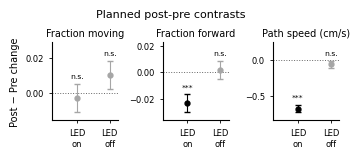

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --------------------------------------------------
# Source dataframe
# --------------------------------------------------

contrast_df = led_anchor_refined_contrasts_corrected_df.copy()

# --------------------------------------------------
# Keep primary locomotor measures and LED transition anchors only
# --------------------------------------------------

outcome_order = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

outcome_labels = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Path speed (cm/s)",
}

anchor_order = [
    "LED_on",
    "LED_off",
]

anchor_labels = {
    "LED_on": "LED\non",
    "LED_off": "LED\noff",
}

plot_df = contrast_df[
    contrast_df["outcome"].isin(outcome_order) &
    contrast_df["anchor_name"].isin(anchor_order)
].copy()

# Make sure p-values are numeric
plot_df["p.value"] = pd.to_numeric(plot_df["p_holm_within_outcome"], errors="coerce")

plot_df["outcome"] = pd.Categorical(
    plot_df["outcome"],
    categories=outcome_order,
    ordered=True,
)

plot_df["anchor_name"] = pd.Categorical(
    plot_df["anchor_name"],
    categories=anchor_order,
    ordered=True,
)

plot_df = plot_df.sort_values(["outcome", "anchor_name"]).reset_index(drop=True)

# --------------------------------------------------
# Helper for p-value labels
# --------------------------------------------------

def p_to_label(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "n.s."



# --------------------------------------------------
# Plot
# --------------------------------------------------

fig, axes = plt.subplots(
    1,
    3,
    figsize=(3.5, 1.5),
    sharex=True
)

for ax, outcome in zip(axes, outcome_order):

    sub = plot_df[plot_df["outcome"] == outcome].copy()

    x = np.arange(len(anchor_order))

    for i, anchor in enumerate(anchor_order):
        ii = i
        row = sub[sub["anchor_name"] == anchor]

        if row.empty:
            continue

        row = row.iloc[0]

        y = row["estimate"]
        yerr_low = y - row["lower.CL"]
        yerr_high = row["upper.CL"] - y

        is_sig = row["p.value"] < 0.05

        point_color = "black" if is_sig else "0.65"
        line_color = "black" if is_sig else "0.65"

        ax.errorbar(
            ii,
            y,
            yerr=np.array([[yerr_low], [yerr_high]]),
            fmt="o",
            color=point_color,
            ecolor=line_color,
            elinewidth=0.8,
            capsize=2.5,
            markersize=3.5,
            zorder=3
        )

        # p-value label
        y_text = row["upper.CL"] + 0.08 * (sub["upper.CL"].max() - sub["lower.CL"].min())
        ax.text(
            ii,
            y_text,
            p_to_label(row["p.value"]),
            ha="center",
            va="bottom",
            fontsize=5.5,
            rotation=0
        )

    ax.axhline(
        0,
        color="0.4",
        linewidth=0.7,
        linestyle=":",
        zorder=1
    )

    ax.set_title(
        outcome_labels[outcome],
        fontsize=7,
        pad=4
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [anchor_labels[a] for a in anchor_order],
        fontsize=6
    )

    ax.tick_params(
        axis="both",
        width=0.6,
        length=2.5,
        labelsize=6
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Nice y-axis padding
    ymin = sub["lower.CL"].min()
    ymax = sub["upper.CL"].max()
    yrange = ymax - ymin
    ax.set_ylim(ymin - 0.15 * yrange, ymax + 0.35 * yrange)
    ax.set_xlim(-0.75, len(anchor_order) - 0.75)

axes[0].set_ylabel(
    "Post − Pre change",
    fontsize=7
)

fig.suptitle(
    "Planned post-pre contrasts",
    fontsize=8,
    y=0.97,
)

fig.tight_layout(pad=0.5, w_pad=0.8)

# --------------------------------------------------
# Save
# --------------------------------------------------

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig3C_LED_on_off_planned_contrasts_primary_measures.pdf",
    bbox_inches="tight"
)

fig.savefig(
    fig_dir / "Fig3C_LED_on_off_planned_contrasts_primary_measures.png",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [35]:
fig_dir

PosixPath('figure_drafts')

In [39]:
%%R -i led_prepost_df -o led_on_interaction_stats_df -o led_on_interaction_contrasts_df -o led_on_interaction_model_info_df

library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

led_prepost_df$animal <- factor(led_prepost_df$animal)
led_prepost_df$animal_day <- factor(led_prepost_df$animal_day)
led_prepost_df$event_anchor_id <- factor(led_prepost_df$event_anchor_id)

led_prepost_df$anchor_name <- factor(
  led_prepost_df$anchor_name,
  levels = c("LED_on", "LED_on_mid", "LED_off", "LED_off_mid")
)

led_prepost_df$window_position <- factor(
  led_prepost_df$window_position,
  levels = c("pre", "post")
)

# Keep LED-on only
led_on_df <- led_prepost_df %>%
  filter(anchor_name == "LED_on")

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms",
  "mean_speed_net_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(led_on_df)]

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(led_on_df) + 1000,
  pbkrtest.limit = nrow(led_on_df) + 1000
)

# --------------------------------------------------
# Values for estimating LED-on effect at early/mean/late exposure and time
# --------------------------------------------------

exposure_vals <- c(
  early = as.numeric(quantile(led_on_df$exposure_session_c, 0.10, na.rm = TRUE)),
  mean  = 0,
  late  = as.numeric(quantile(led_on_df$exposure_session_c, 0.90, na.rm = TRUE))
)

session_time_vals <- c(
  early = as.numeric(quantile(led_on_df$session_time_10m_c, 0.10, na.rm = TRUE)),
  mean  = 0,
  late  = as.numeric(quantile(led_on_df$session_time_10m_c, 0.90, na.rm = TRUE))
)

# --------------------------------------------------
# Fit models
# --------------------------------------------------

stats_list <- list()
contrast_list <- list()
model_info_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting LED-on interaction model for:", outcome, "\n")
  cat("==============================\n")

  df_i <- led_on_df %>%
    filter(
      !is.na(.data[[outcome]]),
      !is.na(window_position),
      !is.na(exposure_session_c),
      !is.na(session_time_10m_c),
      !is.na(animal),
      !is.na(animal_day),
      !is.na(event_anchor_id)
    )

  cat("n rows:", nrow(df_i), "\n")
  print(table(df_i$window_position))

  formula_text <- paste0(
    outcome,
    " ~ window_position * exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | event_anchor_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = df_i,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  singular_flag <- isSingular(m, tol = 1e-4)

  model_info_list[[outcome]] <- data.frame(
    outcome = outcome,
    n_obs = nobs(m),
    is_singular = singular_flag,
    logLik = as.numeric(logLik(m)),
    AIC = AIC(m),
    BIC = BIC(m),
    row.names = NULL
  )

  cat("Singular fit:", singular_flag, "\n")

  # --------------------------------------------------
  # Fixed effects table
  # --------------------------------------------------

  coef_table <- as.data.frame(summary(m)$coefficients)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    singular_fit = singular_flag,
    row.names = NULL
  )

  # --------------------------------------------------
  # Estimated post-minus-pre LED-on effect at early/mean/late exposure and session time
  # --------------------------------------------------

  emm <- emmeans(
    m,
    ~ window_position | exposure_session_c * session_time_10m_c,
    at = list(
      exposure_session_c = as.numeric(exposure_vals),
      session_time_10m_c = as.numeric(session_time_vals)
    ),
    lmer.df = "satterthwaite"
  )

  ctr <- contrast(
    emm,
    method = list(
      "post_minus_pre" = c(-1, 1)
    ),
    by = c("exposure_session_c", "session_time_10m_c"),
    adjust = "none"
  )

  ctr_df <- as.data.frame(summary(ctr, infer = c(TRUE, TRUE)))

  ctr_df$outcome <- outcome
  ctr_df$singular_fit <- singular_flag

  # Add labels for readability
  ctr_df$exposure_level <- dplyr::case_when(
    abs(ctr_df$exposure_session_c - exposure_vals["early"]) < 1e-8 ~ "early exposure",
    abs(ctr_df$exposure_session_c - exposure_vals["mean"])  < 1e-8 ~ "mean exposure",
    abs(ctr_df$exposure_session_c - exposure_vals["late"])  < 1e-8 ~ "late exposure",
    TRUE ~ as.character(ctr_df$exposure_session_c)
  )

  ctr_df$session_time_level <- dplyr::case_when(
    abs(ctr_df$session_time_10m_c - session_time_vals["early"]) < 1e-8 ~ "early session time",
    abs(ctr_df$session_time_10m_c - session_time_vals["mean"])  < 1e-8 ~ "mean session time",
    abs(ctr_df$session_time_10m_c - session_time_vals["late"])  < 1e-8 ~ "late session time",
    TRUE ~ as.character(ctr_df$session_time_10m_c)
  )

  contrast_list[[outcome]] <- ctr_df
}

led_on_interaction_stats_df <- bind_rows(stats_list)
led_on_interaction_contrasts_df <- bind_rows(contrast_list)
led_on_interaction_model_info_df <- bind_rows(model_info_list)

cat("\n\n===== Model info =====\n")
print(led_on_interaction_model_info_df)

cat("\n\n===== Key interaction terms =====\n")
print(
  led_on_interaction_stats_df %>%
    filter(grepl("window_positionpost", term))
)

cat("\n\n===== Estimated LED-on post-minus-pre contrasts =====\n")
print(led_on_interaction_contrasts_df)



Fitting LED-on interaction model for: frac_moving 
n rows: 5842 

 pre post 
2921 2921 
Singular fit: FALSE 


Fitting LED-on interaction model for: frac_forward 
n rows: 5842 

 pre post 
2921 2921 
Singular fit: FALSE 


Fitting LED-on interaction model for: mean_speed_path_cms 
n rows: 5842 

 pre post 
2921 2921 
Singular fit: FALSE 


Fitting LED-on interaction model for: mean_speed_net_cms 
n rows: 5842 

 pre post 
2921 2921 
Singular fit: FALSE 


===== Model info =====
              outcome n_obs is_singular      logLik        AIC         BIC
1         frac_moving  5842       FALSE   -646.0925  1316.1849  1396.25888
2        frac_forward  5842       FALSE     69.1001  -114.2002   -34.12626
3 mean_speed_path_cms  5842       FALSE -11647.9812 23319.9623 23400.03626
4  mean_speed_net_cms  5842       FALSE -12142.5304 24309.0608 24389.13477


===== Key interaction terms =====
[1] outcome      term         beta         se           df          
[6] t            p            n_obs

In [40]:
sig_all_fixed_effects = led_on_interaction_stats_df[
    led_on_interaction_stats_df["p"] < 0.05
].copy()

display(
    sig_all_fixed_effects[
        [
            "outcome",
            "term",
            "beta",
            "se",
            "df",
            "t",
            "p",
            "singular_fit",
        ]
    ]
)

,outcome,term,beta,se,df,t,p,singular_fit
1,frac_moving,(Intercept),0.326517,0.089492,4.999950,3.648560,1.477077e-02,False
3,frac_moving,exposure_session_c,0.016981,0.002838,77.324383,5.983076,6.411819e-08,False
4,frac_moving,session_time_10m_c,-0.041898,0.009629,2849.773241,-4.351279,1.401051e-05,False
5,frac_moving,window_position.L:exposure_session_c,-0.001436,0.000639,2921.000377,-2.249082,2.458151e-02,False
9,frac_forward,(Intercept),0.255989,0.080871,5.002537,3.165391,2.492616e-02,False
10,frac_forward,window_position.L,-0.016524,0.002880,2921.000357,-5.736811,1.063609e-08,False
11,frac_forward,exposure_session_c,0.018211,0.002821,78.132979,6.456275,8.314269e-09,False
12,frac_forward,session_time_10m_c,-0.025457,0.008196,2848.352191,-3.106004,1.915007e-03,False
13,frac_forward,window_position.L:exposure_session_c,-0.002915,0.000585,2921.000357,-4.982682,6.636220e-07,False
18,mean_speed_path_cms,window_position.L,-0.484071,0.026054,2921.000184,-18.579485,6.393990e-73,False


In [9]:
%%R -i led_prepost_df -o led_on_interaction_stats_df -o led_on_interaction_key_stats_df -o led_on_interaction_contrasts_df -o led_on_interaction_contrasts_figD_df -o led_on_interaction_model_info_df
# %%R -i led_prepost_df -o led_off_interaction_stats_df -o led_off_interaction_contrasts_df -o led_off_interaction_model_info_df



library(lme4)
library(lmerTest)
library(dplyr)
library(emmeans)

# --------------------------------------------------
# Prepare data
# --------------------------------------------------

led_prepost_df$animal <- factor(led_prepost_df$animal)
led_prepost_df$animal_day <- factor(led_prepost_df$animal_day)
led_prepost_df$event_anchor_id <- factor(led_prepost_df$event_anchor_id)

led_prepost_df$anchor_name <- factor(
  as.character(led_prepost_df$anchor_name),
  levels = c("LED_on", "LED_on_mid", "LED_off", "LED_off_mid")
)

# IMPORTANT: make this unordered so R uses window_positionpost
led_prepost_df$window_position <- factor(
  as.character(led_prepost_df$window_position),
  levels = c("pre", "post"),
  ordered = FALSE
)

# Keep LED-off only
led_off_df <- led_prepost_df %>%
  filter(anchor_name == "LED_off")

primary_outcomes <- c(
  "frac_moving",
  "frac_forward",
  "mean_speed_path_cms",
  "mean_speed_net_cms"
)

primary_outcomes <- primary_outcomes[primary_outcomes %in% names(led_off_df)]

emm_options(
  lmer.df = "satterthwaite",
  lmerTest.limit = nrow(led_off_df) + 1000,
  pbkrtest.limit = nrow(led_off_df) + 1000
)

# --------------------------------------------------
# Values for estimating LED-off effect
# --------------------------------------------------

exposure_vals <- c(
  early = as.numeric(quantile(led_off_df$exposure_session_c, 0.10, na.rm = TRUE)),
  mean  = 0,
  late  = as.numeric(quantile(led_off_df$exposure_session_c, 0.90, na.rm = TRUE))
)

session_time_vals <- c(
  early = as.numeric(quantile(led_off_df$session_time_10m_c, 0.10, na.rm = TRUE)),
  mean  = 0,
  late  = as.numeric(quantile(led_off_df$session_time_10m_c, 0.90, na.rm = TRUE))
)

# --------------------------------------------------
# Fit models
# --------------------------------------------------

stats_list <- list()
contrast_list <- list()
model_info_list <- list()

for (outcome in primary_outcomes) {

  cat("\n\n==============================\n")
  cat("Fitting LED-off interaction model for:", outcome, "\n")
  cat("==============================\n")

  df_i <- led_off_df %>%
    filter(
      !is.na(.data[[outcome]]),
      !is.na(window_position),
      !is.na(exposure_session_c),
      !is.na(session_time_10m_c),
      !is.na(animal),
      !is.na(animal_day),
      !is.na(event_anchor_id)
    )

  cat("n rows:", nrow(df_i), "\n")
  print(table(df_i$window_position))

  formula_text <- paste0(
    outcome,
    " ~ window_position * exposure_session_c * session_time_10m_c + ",
    "(1 | animal) + (1 | animal_day) + (1 | event_anchor_id)"
  )

  m <- lmer(
    as.formula(formula_text),
    data = df_i,
    REML = FALSE,
    control = lmerControl(
      optimizer = "bobyqa",
      optCtrl = list(maxfun = 2e5)
    )
  )

  singular_flag <- isSingular(m, tol = 1e-4)

  model_info_list[[outcome]] <- data.frame(
    outcome = outcome,
    n_obs = nobs(m),
    is_singular = singular_flag,
    logLik = as.numeric(logLik(m)),
    AIC = AIC(m),
    BIC = BIC(m),
    row.names = NULL
  )

  coef_table <- as.data.frame(summary(m)$coefficients)

  stats_list[[outcome]] <- data.frame(
    outcome = outcome,
    term = rownames(coef_table),
    beta = coef_table[, "Estimate"],
    se = coef_table[, "Std. Error"],
    df = coef_table[, "df"],
    t = coef_table[, "t value"],
    p = coef_table[, "Pr(>|t|)"],
    n_obs = nobs(m),
    singular_fit = singular_flag,
    row.names = NULL
  )

  # Estimated post-minus-pre LED-off effect at early/mean/late exposure and session time
  emm <- emmeans(
    m,
    ~ window_position | exposure_session_c * session_time_10m_c,
    at = list(
      exposure_session_c = as.numeric(exposure_vals),
      session_time_10m_c = as.numeric(session_time_vals)
    ),
    lmer.df = "satterthwaite"
  )

  ctr <- contrast(
    emm,
    method = list(
      "post_minus_pre" = c(-1, 1)
    ),
    by = c("exposure_session_c", "session_time_10m_c"),
    adjust = "none"
  )

  ctr_df <- as.data.frame(summary(ctr, infer = c(TRUE, TRUE)))
  ctr_df$outcome <- outcome
  ctr_df$singular_fit <- singular_flag

  ctr_df$exposure_level <- dplyr::case_when(
    abs(ctr_df$exposure_session_c - exposure_vals["early"]) < 1e-8 ~ "early exposure",
    abs(ctr_df$exposure_session_c - exposure_vals["mean"])  < 1e-8 ~ "mean exposure",
    abs(ctr_df$exposure_session_c - exposure_vals["late"])  < 1e-8 ~ "late exposure",
    TRUE ~ as.character(ctr_df$exposure_session_c)
  )

  ctr_df$session_time_level <- dplyr::case_when(
    abs(ctr_df$session_time_10m_c - session_time_vals["early"]) < 1e-8 ~ "early session time",
    abs(ctr_df$session_time_10m_c - session_time_vals["mean"])  < 1e-8 ~ "mean session time",
    abs(ctr_df$session_time_10m_c - session_time_vals["late"])  < 1e-8 ~ "late session time",
    TRUE ~ as.character(ctr_df$session_time_10m_c)
  )

  contrast_list[[outcome]] <- ctr_df
}

# led_off_interaction_stats_df <- bind_rows(stats_list)
# led_off_interaction_contrasts_df <- bind_rows(contrast_list)
# led_off_interaction_model_info_df <- bind_rows(model_info_list)

# cat("\n\n===== Model info =====\n")
# print(led_off_interaction_model_info_df)

# cat("\n\n===== Key window-related fixed effects =====\n")
# print(
#   led_off_interaction_stats_df %>%
#     filter(grepl("window_position", term))
# )

# cat("\n\n===== Estimated LED-off post-minus-pre contrasts =====\n")
# print(led_off_interaction_contrasts_df)

led_on_interaction_stats_df <- bind_rows(stats_list)
led_on_interaction_contrasts_df <- bind_rows(contrast_list)
led_on_interaction_model_info_df <- bind_rows(model_info_list)

# --------------------------------------------------
# Holm correction for key model interaction terms
# --------------------------------------------------

key_interaction_terms <- c(
  "window_positionpost:exposure_session_c",
  "window_positionpost:session_time_10m_c",
  "window_positionpost:exposure_session_c:session_time_10m_c"
)

led_on_interaction_key_stats_df <- led_on_interaction_stats_df %>%
  filter(term %in% key_interaction_terms) %>%
  group_by(term) %>%
  mutate(
    p_holm_across_outcomes = p.adjust(p, method = "holm")
  ) %>%
  ungroup()

# --------------------------------------------------
# Holm correction for all estimated contrasts
# --------------------------------------------------
# This corrects across the full 3 exposure x 3 session-time grid
# within each outcome.

led_on_interaction_contrasts_df <- led_on_interaction_contrasts_df %>%
  group_by(outcome) %>%
  mutate(
    p_holm_all_grid_within_outcome = p.adjust(p.value, method = "holm")
  ) %>%
  ungroup()

# --------------------------------------------------
# Holm correction for Figure 3D contrasts only
# --------------------------------------------------
# Figure 3D uses early/mean/late exposure at mean session time.
# Correct across those 3 exposure levels within each outcome.

led_on_interaction_contrasts_figD_df <- led_on_interaction_contrasts_df %>%
  filter(
    session_time_level == "mean session time",
    outcome %in% c("frac_forward", "mean_speed_path_cms")
  ) %>%
  group_by(outcome) %>%
  mutate(
    p_holm_figD = p.adjust(p.value, method = "holm")
  ) %>%
  ungroup()



Fitting LED-off interaction model for: frac_moving 
n rows: 5738 

 pre post 
2869 2869 


Fitting LED-off interaction model for: frac_forward 
n rows: 5738 

 pre post 
2869 2869 


Fitting LED-off interaction model for: mean_speed_path_cms 
n rows: 5738 

 pre post 
2869 2869 


Fitting LED-off interaction model for: mean_speed_net_cms 
n rows: 5738 

 pre post 
2869 2869 


In [46]:
sig_led_off_interactions = led_off_interaction_stats_df[
    (led_off_interaction_stats_df["p"] < 0.05) &
    (
        led_off_interaction_stats_df["term"]
        .astype(str)
        .str.contains("window_position", case=False, na=False)
    )
].copy()

display(
    sig_led_off_interactions[
        [
            "outcome",
            "term",
            "beta",
            "se",
            "df",
            "t",
            "p",
            "singular_fit",
        ]
    ]
)

,outcome,term,beta,se,df,t,p,singular_fit
2,frac_moving,window_positionpost,0.010478,0.004121,2869.000315,2.542462,0.011060,False
18,mean_speed_path_cms,window_positionpost,-0.057890,0.024373,2869.000188,-2.375193,0.017605,False
21,mean_speed_path_cms,window_positionpost:exposure_session_c,-0.011937,0.004952,2869.000188,-2.410346,0.016000,False
26,mean_speed_net_cms,window_positionpost,-0.072277,0.027074,2868.999958,-2.669586,0.007637,False
29,mean_speed_net_cms,window_positionpost:exposure_session_c,-0.016292,0.005501,2868.999958,-2.961434,0.003087,False


In [47]:
sig_led_off_contrasts = led_off_interaction_contrasts_df[
    led_off_interaction_contrasts_df["p.value"] < 0.05
].copy()

display(
    sig_led_off_contrasts[
        [
            "outcome",
            "exposure_level",
            "session_time_level",
            "estimate",
            "SE",
            "df",
            "lower.CL",
            "upper.CL",
            "t.ratio",
            "p.value",
            "singular_fit",
        ]
    ]
)

,outcome,exposure_level,session_time_level,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,singular_fit
5,frac_moving,mean exposure,mean session time,0.010478,0.004121,2869.000315,0.002397,0.018559,2.542462,0.011060,False
23,mean_speed_path_cms,mean exposure,mean session time,-0.057890,0.024373,2869.000188,-0.105681,-0.010100,-2.375193,0.017605,False
24,mean_speed_path_cms,late exposure,mean session time,-0.135453,0.040353,2869.000188,-0.214577,-0.056330,-3.356708,0.000799,False
26,mean_speed_path_cms,mean exposure,late session time,-0.116701,0.041707,2869.000188,-0.198480,-0.034922,-2.798092,0.005175,False
27,mean_speed_path_cms,late exposure,late session time,-0.170699,0.069154,2869.000188,-0.306295,-0.035103,-2.468406,0.013630,False
32,mean_speed_net_cms,mean exposure,mean session time,-0.072277,0.027074,2868.999958,-0.125364,-0.019190,-2.669586,0.007637,False
33,mean_speed_net_cms,late exposure,mean session time,-0.178135,0.044825,2868.999958,-0.266028,-0.090242,-3.973980,0.000072,False
35,mean_speed_net_cms,mean exposure,late session time,-0.139075,0.046330,2868.999958,-0.229918,-0.048233,-3.001872,0.002706,False
36,mean_speed_net_cms,late exposure,late session time,-0.227349,0.076818,2868.999958,-0.377972,-0.076725,-2.959584,0.003106,False


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Combine LED-on and LED-off interaction contrast tables
# ==================================================

plot_parts = []

# LED on
led_on_plot = led_on_interaction_contrasts_df.copy()
led_on_plot["anchor_name"] = "LED_on"
plot_parts.append(led_on_plot)

# LED off, if you already created it with analogous code
try:
    led_off_plot = led_off_interaction_contrasts_df.copy()
    led_off_plot["anchor_name"] = "LED_off"
    plot_parts.append(led_off_plot)
except NameError:
    print("led_off_interaction_contrasts_df not found; plotting LED_on only.")

plot_df = pd.concat(plot_parts, ignore_index=True)

# ==================================================
# Keep primary locomotor measures only
# ==================================================

outcome_order = [
    "frac_moving",
    "frac_forward",
    "mean_speed_path_cms",
]

outcome_labels = {
    "frac_moving": "Fraction moving",
    "frac_forward": "Fraction forward",
    "mean_speed_path_cms": "Path speed (cm/s)",
}

anchor_order = ["LED_on", "LED_off"]

anchor_labels = {
    "LED_on": "LED on",
    "LED_off": "LED off",
}

exposure_order = [
    "early exposure",
    "mean exposure",
    "late exposure",
]

exposure_labels = {
    "early exposure": "Early",
    "mean exposure": "Mean",
    "late exposure": "Late",
}

plot_df = plot_df[
    plot_df["outcome"].isin(outcome_order)
].copy()

# Use mean within-session time for the main figure
plot_df = plot_df[
    plot_df["session_time_level"].astype(str).eq("mean session time")
].copy()

plot_df["outcome"] = pd.Categorical(
    plot_df["outcome"],
    categories=outcome_order,
    ordered=True
)

plot_df["anchor_name"] = pd.Categorical(
    plot_df["anchor_name"],
    categories=anchor_order,
    ordered=True
)

plot_df["exposure_level"] = pd.Categorical(
    plot_df["exposure_level"],
    categories=exposure_order,
    ordered=True
)

plot_df["p.value"] = pd.to_numeric(plot_df["p.value"], errors="coerce")

plot_df = plot_df.sort_values(
    ["outcome", "anchor_name", "exposure_level"]
).reset_index(drop=True)

display(plot_df)

led_off_interaction_contrasts_df not found; plotting LED_on only.


,contrast,exposure_session_c,session_time_10m_c,estimate,SE,df,lower.CL,upper.CL,t.ratio,p.value,outcome,singular_fit,exposure_level,session_time_level,p_holm_all_grid_within_outcome,anchor_name
0,post_minus_pre,-6.502338,0.0,0.011162,0.006831,2869.000315,-0.002232,0.024557,1.633986,0.102371,frac_moving,False,early exposure,mean session time,0.716600,LED_on
1,post_minus_pre,0.000000,0.0,0.010478,0.004121,2869.000315,0.002397,0.018559,2.542462,0.011060,frac_moving,False,mean exposure,mean session time,0.099536,LED_on
2,post_minus_pre,6.497662,0.0,0.009794,0.006823,2869.000315,-0.003585,0.023173,1.435418,0.151277,frac_moving,False,late exposure,mean session time,0.907662,LED_on
3,post_minus_pre,-6.502338,0.0,0.009033,0.005719,2869.000267,-0.002181,0.020246,1.579423,0.114349,frac_forward,False,early exposure,mean session time,0.914795,LED_on
4,post_minus_pre,0.000000,0.0,0.001950,0.003450,2869.000268,-0.004815,0.008715,0.565225,0.571965,frac_forward,False,mean exposure,mean session time,1.000000,LED_on
5,post_minus_pre,6.497662,0.0,-0.005127,0.005712,2869.000267,-0.016328,0.006073,-0.897607,0.369470,frac_forward,False,late exposure,mean session time,1.000000,LED_on
6,post_minus_pre,-6.502338,0.0,0.019728,0.040401,2869.000188,-0.059489,0.098945,0.488319,0.625361,mean_speed_path_cms,False,early exposure,mean session time,1.000000,LED_on
7,post_minus_pre,0.000000,0.0,-0.057890,0.024373,2869.000188,-0.105681,-0.010100,-2.375193,0.017605,mean_speed_path_cms,False,mean exposure,mean session time,0.105631,LED_on
8,post_minus_pre,6.497662,0.0,-0.135453,0.040353,2869.000188,-0.214577,-0.056330,-3.356708,0.000799,mean_speed_path_cms,False,late exposure,mean session time,0.007191,LED_on


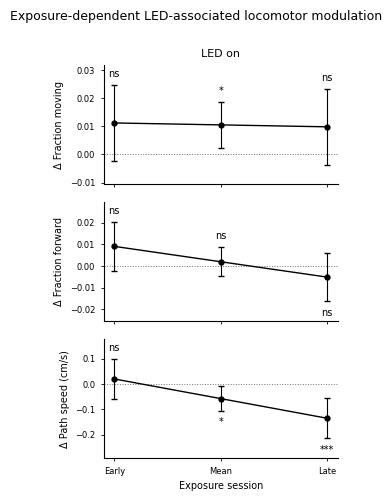

In [14]:
# ==================================================
# Helper
# ==================================================

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

# ==================================================
# Plot model-estimated post-minus-pre effect
# ==================================================

anchors_present = [a for a in anchor_order if a in plot_df["anchor_name"].astype(str).unique()]
n_cols = len(anchors_present)

fig, axes = plt.subplots(
    nrows=3,
    ncols=n_cols,
    figsize=(3.0 * n_cols, 4.8),
    sharex=True
)

if n_cols == 1:
    axes = np.array(axes).reshape(3, 1)

x = np.arange(len(exposure_order))

for row_i, outcome in enumerate(outcome_order):
    for col_i, anchor in enumerate(anchors_present):

        ax = axes[row_i, col_i]

        sub = plot_df[
            (plot_df["outcome"] == outcome) &
            (plot_df["anchor_name"].astype(str) == anchor)
        ].copy()

        sub = (
            sub.set_index("exposure_level")
            .reindex(exposure_order)
            .reset_index()
        )

        y = sub["estimate"].astype(float).to_numpy()
        ylo = sub["lower.CL"].astype(float).to_numpy()
        yhi = sub["upper.CL"].astype(float).to_numpy()
        pvals = sub["p.value"].astype(float).to_numpy()

        yerr = np.vstack([
            y - ylo,
            yhi - y
        ])

        ax.errorbar(
            x,
            y,
            yerr=yerr,
            fmt="o-",
            color="black",
            ecolor="black",
            elinewidth=0.8,
            linewidth=1.0,
            markersize=3.5,
            capsize=2.5,
            zorder=3
        )

        ax.axhline(
            0,
            color="0.45",
            linewidth=0.7,
            linestyle=":",
            zorder=1
        )

        # Significance stars for post-minus-pre contrast
        finite_vals = np.concatenate([ylo[np.isfinite(ylo)], yhi[np.isfinite(yhi)]])
        if len(finite_vals) > 0:
            ymin = np.nanmin(finite_vals)
            ymax = np.nanmax(finite_vals)
        else:
            ymin, ymax = -1, 1

        yrange = ymax - ymin if ymax > ymin else 1

        for i, p in enumerate(pvals):
            stars = p_to_stars(p)
            if stars:
                if y[i] >= 0:
                    y_text = yhi[i] + 0.08 * yrange
                    va = "bottom"
                else:
                    y_text = ylo[i] - 0.08 * yrange
                    va = "top"

                ax.text(
                    x[i],
                    y_text,
                    stars,
                    ha="center",
                    va=va,
                    fontsize=7
                )

        if row_i == 0:
            ax.set_title(anchor_labels.get(anchor, anchor), fontsize=8)

        if col_i == 0:
            ax.set_ylabel(
                f"Δ {outcome_labels[outcome]}",
                fontsize=7
            )

        if row_i == len(outcome_order) - 1:
            ax.set_xticks(x)
            ax.set_xticklabels(
                [exposure_labels[e] for e in exposure_order],
                fontsize=6
            )
            ax.set_xlabel("Exposure session", fontsize=7)

        ax.tick_params(
            axis="both",
            width=0.6,
            length=2.5,
            labelsize=6
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        ax.set_ylim(
            ymin - 0.25 * yrange,
            ymax + 0.25 * yrange
        )

fig.suptitle(
    "Exposure-dependent LED-associated locomotor modulation",
    fontsize=9,
    y=1.02
)

fig.tight_layout(pad=0.6, w_pad=0.9, h_pad=1.0)

# ==================================================
# Save
# ==================================================

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig_LED_onoff_exposure_dependent_primary_measures.pdf",
    bbox_inches="tight"
)

/

plt.show()

,outcome,exposure_level,estimate,SE,lower.CL,upper.CL,p.value,p_holm_figD
0,frac_forward,early exposure,0.009033,0.005719,-0.002181,0.020246,0.114349,0.343048
1,frac_forward,mean exposure,0.001950,0.003450,-0.004815,0.008715,0.571965,0.738941
2,frac_forward,late exposure,-0.005127,0.005712,-0.016328,0.006073,0.369470,0.738941
3,mean_speed_path_cms,early exposure,0.019728,0.040401,-0.059489,0.098945,0.625361,0.625361
4,mean_speed_path_cms,mean exposure,-0.057890,0.024373,-0.105681,-0.010100,0.017605,0.035210
5,mean_speed_path_cms,late exposure,-0.135453,0.040353,-0.214577,-0.056330,0.000799,0.002397


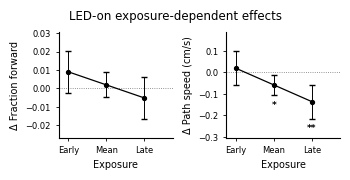

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ==================================================
# Compact Panel D: LED-on exposure-dependent effects
# ==================================================

panelD_outcomes = [
    "frac_forward",
    "mean_speed_path_cms",
]

panelD_labels = {
    "frac_forward": "Δ Fraction forward",
    "mean_speed_path_cms": "Δ Path speed (cm/s)",
}

exposure_order = [
    "early exposure",
    "mean exposure",
    "late exposure",
]

exposure_labels = {
    "early exposure": "Early",
    "mean exposure": "Mean",
    "late exposure": "Late",
}

# --------------------------------------------------
# Keep LED-on only, mean session time only
# --------------------------------------------------

panelD_df = plot_df.copy()

panelD_df = panelD_df[
    (panelD_df["anchor_name"].astype(str) == "LED_on") &
    (panelD_df["outcome"].isin(panelD_outcomes))
].copy()

if "session_time_level" in panelD_df.columns:
    panelD_df = panelD_df[
        panelD_df["session_time_level"].astype(str).eq("mean session time")
    ].copy()

panelD_df["exposure_level"] = pd.Categorical(
    panelD_df["exposure_level"],
    categories=exposure_order,
    ordered=True
)

panelD_df["outcome"] = pd.Categorical(
    panelD_df["outcome"],
    categories=panelD_outcomes,
    ordered=True
)

panelD_df["p.value"] = pd.to_numeric(panelD_df["p.value"], errors="coerce")


# --------------------------------------------------
# Holm correction for Panel D
# Correct across early/mean/late exposure within each outcome
# --------------------------------------------------

def holm_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    adjusted = np.full_like(pvals, np.nan, dtype=float)

    valid = ~np.isnan(pvals)
    p = pvals[valid]

    m = len(p)
    if m == 0:
        return adjusted

    order = np.argsort(p)
    ranked_p = p[order]

    holm_sorted = (m - np.arange(m)) * ranked_p
    holm_sorted = np.maximum.accumulate(holm_sorted)
    holm_sorted = np.minimum(holm_sorted, 1.0)

    adjusted_valid = np.empty_like(p)
    adjusted_valid[order] = holm_sorted

    adjusted[valid] = adjusted_valid
    return adjusted


panelD_df["p_holm_figD"] = np.nan

for outcome, idx in panelD_df.groupby("outcome").groups.items():
    panelD_df.loc[idx, "p_holm_figD"] = holm_adjust(
        panelD_df.loc[idx, "p.value"].to_numpy()
    )



panelD_df = panelD_df.sort_values(
    ["outcome", "exposure_level"]
).reset_index(drop=True)

# display(panelD_df)

display(
    panelD_df[
        [
            "outcome",
            "exposure_level",
            "estimate",
            "SE",
            "lower.CL",
            "upper.CL",
            "p.value",
            "p_holm_figD",
        ]
    ]
)

# ==================================================
# Helper
# ==================================================

def p_to_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

# ==================================================
# Plot
# ==================================================

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(3.4, 1.5),
    sharex=True
)

x = np.arange(len(exposure_order))

for ax, outcome in zip(axes, panelD_outcomes):

    sub = panelD_df[
        panelD_df["outcome"] == outcome
    ].copy()

    sub = (
        sub.set_index("exposure_level")
        .reindex(exposure_order)
        .reset_index()
    )

    y = sub["estimate"].astype(float).to_numpy()
    ylo = sub["lower.CL"].astype(float).to_numpy()
    yhi = sub["upper.CL"].astype(float).to_numpy()
    # pvals = sub["p.value"].astype(float).to_numpy()
    pvals = sub["p_holm_figD"].astype(float).to_numpy()

    yerr = np.vstack([
        y - ylo,
        yhi - y
    ])

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        fmt="o-",
        color="black",
        ecolor="black",
        elinewidth=0.7,
        linewidth=0.9,
        markersize=2.8,
        capsize=2.0,
        zorder=3
    )

    ax.axhline(
        0,
        color="0.45",
        linewidth=0.6,
        linestyle=":",
        zorder=1
    )

    # Significance stars
    ymin = np.nanmin(ylo)
    ymax = np.nanmax(yhi)
    yrange = ymax - ymin if ymax > ymin else 1

    for i, p in enumerate(pvals):
        stars = p_to_stars(p)
        if stars:
            if y[i] >= 0:
                y_text = yhi[i] + 0.08 * yrange
                va = "bottom"
            else:
                y_text = ylo[i] - 0.08 * yrange
                va = "top"

            ax.text(
                x[i],
                y_text,
                stars,
                ha="center",
                va=va,
                fontsize=6.5,
                fontweight="bold"
            )

    ax.set_ylabel(
        panelD_labels[outcome],
        fontsize=7
    )

    ax.set_xticks(x)
    ax.set_xticklabels(
        [exposure_labels[e] for e in exposure_order],
        fontsize=6
    )

    ax.set_xlabel(
        "Exposure",
        fontsize=7
    )

    ax.tick_params(
        axis="both",
        width=0.6,
        length=2.2,
        labelsize=6
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.set_ylim(
        ymin - 0.28 * yrange,
        ymax + 0.28 * yrange
    )

    ax.set_xlim(-0.25, len(exposure_order) - 0.25)

fig.tight_layout(pad=0.35, w_pad=0.7)
fig.suptitle(
    "LED-on exposure-dependent effects",
    fontsize=8.5,
    y=1.1
)

# ==================================================
# Save
# ==================================================

try:
    fig_dir = Path(fig_dir_str)
except NameError:
    fig_dir = Path("figure_drafts")

fig_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(
    fig_dir / "Fig3D_LED_on_exposure_dependent_fraction_forward_path_speed.pdf",
    bbox_inches="tight"
)

# fig.savefig(
#     fig_dir / "Fig3D_LED_on_exposure_dependent_fraction_forward_path_speed.png",
#     dpi=600,
#     bbox_inches="tight"
# )

plt.show()